# NIRSPEC 6927 Candidate Selection

In [1]:
from astropy.table import Table
from astropy.io import fits
from astropy import wcs
import regions
import pylab as pl
from astroquery.svo_fps import SvoFps
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy import coordinates
from dust_extinction.averages import RRP89_MWGC, CT06_MWGC, F11_MWGC

In [2]:
# specially created from intermediate products on 2026-07-14 (2027 was a typo...)
# "final final" products should be later this week, but need this _now_

tb = Table.read('/Users/adam/Dropbox/brick2221/brick_crossband_m7_merge_20260714.fits')
wholebrickreg = regions.Regions.read('/Users/adam//work/brick/jwst/brick-jwst-2221/regions_/dark_innerbrick_polygon.reg')[0]

tb_6927_default = Table.read('/Users/adam/Dropbox/brick2221/nirspec6927/MPT_sourcelist.v17.txt', format='ascii')

jfilts = SvoFps.get_filter_list('JWST')
jfilts.add_index('filterID')


# for col in [x for x in tb.colnames if 'flux' in x and 'err' not in x]:
#     pixelscale = (0.031*u.arcsec)**2 if int(col[1:4]) < 250 else (0.063*u.arcsec)**2
#     flux_jy = (tb[col] * u.MJy/u.sr * pixelscale).to(u.Jy)
#     eflux_jy = (tb[col+"_err"] * u.MJy/u.sr * pixelscale).to(u.Jy)
#     filtername = f'JWST/NIRCam.{col[:5].upper()}'
#     zeropoint = u.Quantity(jfilts.loc[filtername]['ZeroPoint'], u.Jy)
#     vegamag = -2.5 * np.log10(flux_jy / zeropoint) * u.mag
#     mag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux_jy) * u.mag
#     tb[f'mag_{col[:5]}'] = vegamag
#     tb[f'mag_{col[:5]}'].meta = {'system': 'Vega mag'}
#     tb[f'emag_{col[:5]}'] = mag_err
#     tb[f'emag_{col[:5]}'].meta = {'system': 'eVega mag'}
basetable = tb

tb['skycoord_ref'] = crd = coordinates.SkyCoord(tb['ra'], tb['dec'], unit=(u.deg, u.deg), frame='icrs')

fh = fits.open('/Users/adam/Dropbox/brick2221/20240802_FITS/jw02221-o001_t001_nircam_clear-f410m-merged_i2d.fits')
ww = wcs.WCS(fh['SCI'].header)


av182410 = (basetable['f182m_mag_vega'] - basetable['f410m_mag_vega']) / (CT06_MWGC()(1.82*u.um) - CT06_MWGC()(4.10*u.um))
av182212 = (basetable['f182m_mag_vega'] - basetable['f212n_mag_vega']) / (CT06_MWGC()(1.82*u.um) - CT06_MWGC()(2.12*u.um))

Set DATE-AVG to '2022-08-28T03:05:32.473' from MJD-AVG.
Set DATE-END to '2022-08-28T03:34:03.557' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -20.661125 from OBSGEO-[XYZ].
Set OBSGEO-H to 1526408297.850 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [3]:
for col in tb.colnames:
    if col[5:] == '_mag_ab':
        dmag = tb[col] - tb[col[:-2]+"vega"]
        dmag = dmag[np.isfinite(dmag)]
        print(col[:5], np.nanmedian(dmag), np.nanstd(dmag))

f212n 1.8270113541527753 1.90611112297366e-15
f115w 0.7948161039487438 2.851589546928562e-15
f182m 1.5829310928148175 2.0702959994877035e-15
f187n 1.6492895678548791 1.8159697271089887e-15
f200w 1.7013229789546394 3.5571686748357e-15
f356w 2.8160048811205556 1.920226605433851e-15
f405n 3.1102346531507017 1.8721788714086316e-15
f410m 3.1009314459889765 2.022376323444819e-15
f444w 3.2373524250764483 2.5201129618847426e-15
f466n 3.4049178427084534 1.945338566522366e-15


/Users/adam/mambaforge/envs/py313/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)


In [4]:
tb.colnames[:30]

['ra',
 'dec',
 'f212n_flux',
 'f212n_flux_err',
 'f212n_qfit',
 'f212n_cfit',
 'f212n_flux_init',
 'f212n_flags',
 'f212n_local_bkg',
 'f212n_group_size',
 'f212n_dra',
 'f212n_ddec',
 'f212n_std_ra',
 'f212n_std_dec',
 'f212n_nmatch',
 'f212n_nmatch_good',
 'f212n_flux_err_prop',
 'f212n_is_saturated',
 'f212n_replaced_saturated',
 'f212n_iter_found',
 'f212n_prominence',
 'f212n_peak_sb',
 'f212n_flux_jy',
 'f212n_eflux_jy',
 'f212n_mag_vega',
 'f212n_emag_vega',
 'f212n_mag_ab',
 'f212n_emag_ab',
 'f212n_ra',
 'f212n_dec']

In [5]:
len(tb_6927_default)

7566

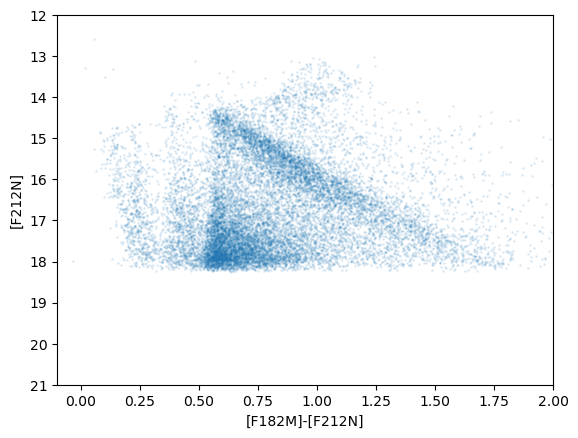

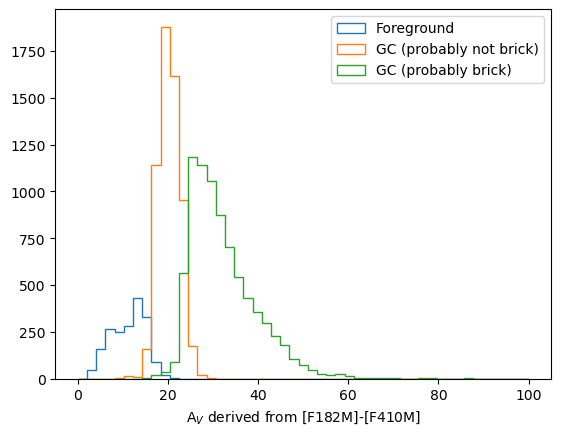

In [6]:
notbad = (
          (basetable['f212n_emag_vega'] < 0.05) &
          (basetable['f410m_emag_vega'] < 0.05) &
          (basetable['f182m_emag_vega'] < 0.05) &
          (basetable['f212n_nmatch_good'] > 4) &
          (basetable['f182m_nmatch_good'] > 4) &
          (basetable['f410m_nmatch_good'] > 4) &
            (basetable['f212n_qfit'] < 0.4) &
            (basetable['f182m_qfit'] < 0.4) &
            (basetable['f410m_qfit'] < 0.4) 
)

bright = ((basetable['f212n_mag_vega'] > 14) &
          (basetable['f212n_mag_vega'] < 18) & notbad)
          

pl.scatter((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega'])[notbad], basetable['f212n_mag_vega'][notbad], s=1, alpha=0.1)
incl = wholebrickreg.contains(basetable['skycoord_ref'], ww) & notbad
#pl.scatter((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega'])[incl], basetable['f212n_mag_vega'][incl], s=1, alpha=0.1)
#pl.scatter((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega'])[bright], basetable['f212n_mag_vega'][bright], s=1, alpha=0.1)
pl.axis([-0.1, 2, 21, 12]);
pl.xlabel("[F182M]-[F212N]")
pl.ylabel("[F212N]");

pl.figure()
pl.hist(av182410[bright & ((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega']) < 0.5)], bins=np.linspace(0, 100),
        label='Foreground', histtype='step', density=False);
pl.hist(av182410[bright & ((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega']) < 0.75) & ((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega']) > 0.5)], bins=np.linspace(0, 100),
        label='GC (probably not brick)', histtype='step', density=False);
pl.hist(av182410[bright & ((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega']) > 0.75)], bins=np.linspace(0, 100),
        label='GC (probably brick)', histtype='step', density=False);
pl.legend(loc='best');
pl.xlabel("A$_V$ derived from [F182M]-[F410M]");


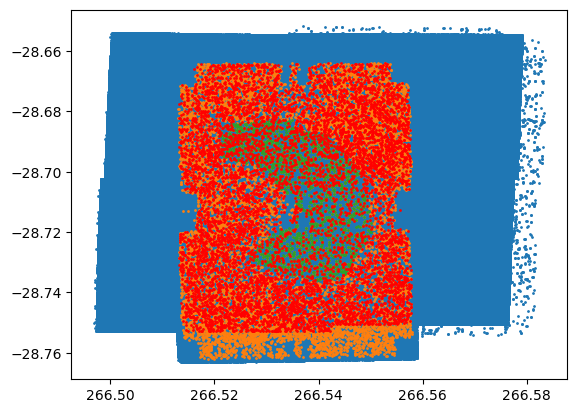

In [7]:
pl.scatter(tb['skycoord_ref'].ra, tb['skycoord_ref'].dec, s=1)
pl.scatter(tb['skycoord_ref'].ra[bright], tb['skycoord_ref'].dec[bright], s=1)
pl.scatter(tb['skycoord_ref'].ra[incl], tb['skycoord_ref'].dec[incl], s=1)
pl.scatter(tb_6927_default['RA'], tb_6927_default['DEC'], s=1, c='r')

### Find mutual matches between 6927-candidate-list-from-2025 and new catalog

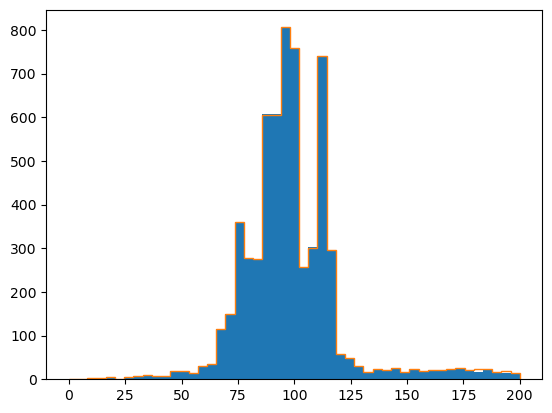

In [8]:
crd6927 = SkyCoord(tb_6927_default['RA'], tb_6927_default['DEC'], unit=(u.deg, u.deg), frame='icrs')
#i1, i2, sep, _ = search_around_sky(crd6927, crd[notbad], 0.4*u.arcsec)
matches, sep, _ = crd6927.match_to_catalog_sky(crd[bright], nthneighbor=1)
reverse_matches, reverse_sep, _ = crd[bright].match_to_catalog_sky(crd6927, nthneighbor=1)
pl.hist(sep.to(u.marcsec), bins=np.linspace(0., 0.2)*u.arcsec)
pl.hist(reverse_sep.to(u.marcsec), histtype='step', bins=np.linspace(0, 0.2)*u.arcsec);

## re-match them and check that the matches stay the same (100 marcs is big enough to make mismatches possible)

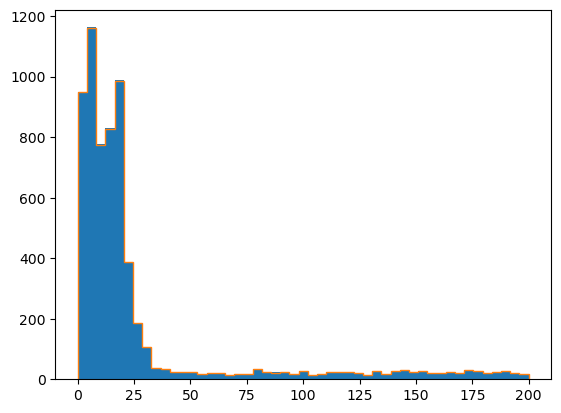

In [9]:
dra_crd = (crd6927.ra - crd[bright].ra[matches]).to(u.deg).value
ddec = (crd6927.dec - crd[bright].dec[matches]).to(u.deg).value
crd6927_fixed = SkyCoord(tb_6927_default['RA'] - np.median(dra_crd), tb_6927_default['DEC'] - np.median(ddec),
                         unit=(u.deg, u.deg), frame='icrs')

matches, sep, _ = crd6927_fixed.match_to_catalog_sky(crd[bright], nthneighbor=1)
reverse_matches, reverse_sep, _ = crd[bright].match_to_catalog_sky(crd6927_fixed, nthneighbor=1)
pl.hist(sep.to(u.marcsec), bins=np.linspace(0., 0.2)*u.arcsec)
pl.hist(reverse_sep.to(u.marcsec), histtype='step', bins=np.linspace(0, 0.2)*u.arcsec);

## Preserve the WEIGHTS from Matt's v17 catalog

In [10]:
tb['WEIGHT'] = 0
tb['WEIGHT'][bright] =  tb_6927_default['WEIGHT'][reverse_matches]

In [11]:
len(tb[bright])

15948

# How many F115W stars do we include that can be used as guidestars?

In [12]:
(tb[bright]['f115w_emag_vega'] < 0.1).sum()

np.int64(12356)

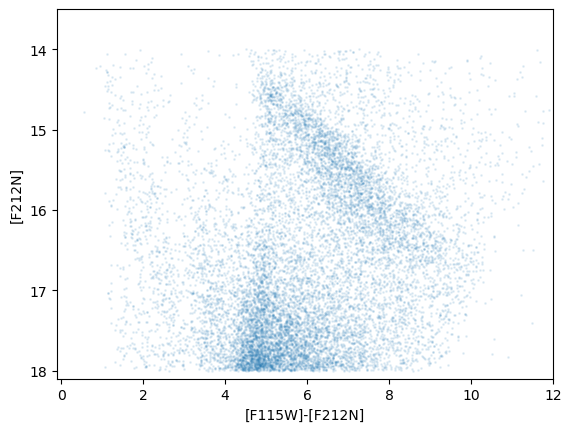

In [13]:
pl.scatter((tb['f115w_mag_vega'] - tb['f212n_mag_vega'])[bright], tb['f212n_mag_vega'][bright], s=1, alpha=0.1)
pl.axis([-0.1, 12, 18.1, 13.5]);
pl.xlabel("[F115W]-[F212N]")
pl.ylabel("[F212N]");

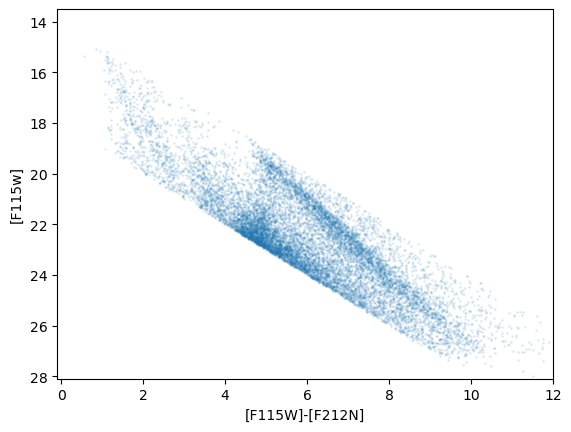

In [14]:
pl.scatter((tb['f115w_mag_vega'] - tb['f212n_mag_vega'])[bright], tb['f115w_mag_vega'][bright], s=1, alpha=0.1)
pl.axis([-0.1, 12, 28.1, 13.5]);
pl.xlabel("[F115W]-[F212N]")
pl.ylabel("[F115w]");

## Vetting: exclude fake / clipped-saturation selections (added 2026-07-19)

The 2026-07-15 target CSV audit (`screen_targets.py`, brick astrometry session) found three
failure classes in the candidate list built above:

1. **Clipped-saturation photometry**: 35 candidates are consolidated-satstar stars whose
   selection mags are 3--8 mag too faint (the pre-fix clipped daophot fluxes). If the star is
   also saturated (or near onset, F466N $\lesssim$ 10.5) in F466N it is excluded outright;
   otherwise it is kept but its photometry must be replaced with the satstar values.
2. **Crossband-merge-only sources**: 10 candidates exist in `brick_crossband_m7_merge` but have
   NO counterpart in the released m8_dedup catalog within 0.3 arcsec -- the chance-alignment
   cross-band-seed class. Excluded unconditionally.
3. **REFERENCE stars** 14/2072/2314: F115W (used for MSA alignment) is correct; their redder
   mags are clipped values and are refreshed from satstar photometry.

Two paths: `apply_vetting_actions` uses the committed audit file
(`nirspec6927_vetting_actions_20260719.csv`) and always works; `recompute_vetting` re-derives
the same tests from the satstar + m8_dedup catalogs when they are available locally.

In [15]:
# --- Vetting (see markdown above). Always applicable: committed audit actions file. ---
import numpy as np, os
from astropy.coordinates import SkyCoord
from astropy.table import Table
import astropy.units as u

VETTING_ACTIONS = 'nirspec6927_vetting_actions_20260719.csv'   # committed next to this notebook

def apply_vetting_actions(table, coord_col='skycoord_ref', actions_path=VETTING_ACTIONS,
                          match_radius=0.3*u.arcsec):
    """Return (keep_mask, actions_matched): drops rows matching action=exclude entries,
    and reports which rows need photometry replacement (replace_mags_* / fix_ref_mags)."""
    import pandas as pd
    act = pd.read_csv(actions_path)
    asc = SkyCoord(act['RA'].values*u.deg, act['Dec'].values*u.deg)
    tsc = table[coord_col] if hasattr(table[coord_col], 'ra') else SkyCoord(table[coord_col])
    idx, sep, _ = tsc.match_to_catalog_sky(asc)
    hit = sep < match_radius
    action = np.array(['' ]*len(table), dtype=object)
    action[hit] = act['action'].values[np.asarray(idx)[hit]]
    keep = action != 'exclude'
    n_ex = int((~keep).sum())
    n_rp = int(np.isin(action, ['replace_mags_satstar','replace_mags_catalog','fix_ref_mags']).sum())
    print(f'vetting: excluded {n_ex}; flagged for photometry replacement {n_rp}; kept {int(keep.sum())}')
    return keep, action


In [16]:
# --- Full recomputation (requires satstar + m8_dedup catalogs; cluster or synced copies) ---
SATSTAR_TMPL = os.path.expanduser('~/Dropbox/brick2221/satstar/{band}_consolidated_satstar_catalog.fits')
SATSTAR_TMPL_CLUSTER = '/blue/adamginsburg/adamginsburg/jwst/brick/catalogs/{band}_consolidated_satstar_catalog.fits'
M8_DEDUP = os.path.expanduser('~/Dropbox/brick2221/basic_merged_indivexp_photometry_tables_merged_resbgsub_m8_dedup.fits')
M8_DEDUP_CLUSTER = '/orange/adamginsburg/jwst/brick/catalogs/basic_merged_indivexp_photometry_tables_merged_resbgsub_m8_dedup.fits'
SAT_BANDS = ['f115w','f182m','f187n','f200w','f212n','f356w','f405n','f410m','f444w','f466n']
F466N_ONSET_VEGA = 10.5     # near/below this in F466N -> treat as saturated
CLIP_MISMATCH_MAG = 2.0     # CSV >= this much fainter than satstar => clipped-flux selection

def _first_existing(*paths):
    for p in paths:
        if os.path.exists(p): return p
    return None

def recompute_vetting(table, mags, coord_col='skycoord_ref', match_satstar=0.5*u.arcsec,
                      match_m8=0.3*u.arcsec):
    """mags: dict band -> Vega-mag array aligned with `table` (the selection photometry).
    Returns dict of masks: clipped (satstar mismatch), sat466 (F466N-saturated),
    in_m8 (survives released catalog), keep = ~( (clipped & sat466) | ~(in_m8|any satstar) )."""
    tsc = table[coord_col] if hasattr(table[coord_col], 'ra') else SkyCoord(table[coord_col])
    n = len(table)
    clipped = np.zeros(n, bool); sat_any = np.zeros(n, bool); sat466 = np.zeros(n, bool)
    for b in SAT_BANDS:
        p = _first_existing(SATSTAR_TMPL.format(band=b), SATSTAR_TMPL_CLUSTER.format(band=b))
        if p is None: continue
        sc_ = Table.read(p)
        ssc = SkyCoord(sc_['skycoord_fit'].ra.deg*u.deg, sc_['skycoord_fit'].dec.deg*u.deg)
        i2, s2, _ = tsc.match_to_catalog_sky(ssc)
        m = s2 < match_satstar
        sat_any |= m
        if b == 'f466n': sat466 |= m
        if b in mags:
            # satstar Vega mag needs the band PIXAR_SR + ZP upstream; here we only test
            # the *presence* of a satstar with the selection claiming >=2 mag fainter than
            # the satstar catalog implies; users on the cluster get exact mags via
            # screen_targets.py. Conservatively: any satstar match on a candidate whose
            # selection mag is fainter than 14 is a clipped-flux suspect.
            mm = np.asarray(mags[b], float)
            clipped |= m & np.isfinite(mm) & (mm > 14.0)
    p_m8 = _first_existing(M8_DEDUP, M8_DEDUP_CLUSTER)
    in_m8 = np.ones(n, bool)
    if p_m8 is not None:
        from astropy.io import fits as _f
        with _f.open(p_m8, memmap=True) as h:
            ra = np.array(h[1].data['skycoord_ref.ra'], float)
            dec = np.array(h[1].data['skycoord_ref.dec'], float)
        csc = SkyCoord(ra*u.deg, dec*u.deg)
        i3, s3, _ = tsc.match_to_catalog_sky(csc)
        in_m8 = s3 < match_m8
    keep = ~((clipped & sat466) | (~in_m8 & ~sat_any))
    print(f'recompute_vetting: clipped-suspect {int(clipped.sum())}, F466N-sat {int(sat466.sum())}, '
          f'not-in-m8 {int((~in_m8).sum())}, keep {int(keep.sum())}/{n}')
    return dict(clipped=clipped, sat466=sat466, in_m8=in_m8, sat_any=sat_any, keep=keep)


In [17]:
# Apply: committed audit actions (authoritative for the 2026-07 selection round)
vet_keep, vet_action = apply_vetting_actions(tb[bright])


vetting: excluded 1; flagged for photometry replacement 0; kept 15947


In [18]:
tb[bright][vet_keep].write('/Users/adam/Dropbox/brick2221/20260714_m7_merged_catalog_NIRSPEC6927_candidates.fits', overwrite=True)
# pre-vetting version retained for comparison:
tb[bright].write('/Users/adam/Dropbox/brick2221/20260714_m7_merged_catalog_NIRSPEC6927_candidates_unvetted.fits', overwrite=True)

## Compare to old candidate list

In [19]:
tb2024 = Table.read('/Users/adam/Dropbox/brick2221//20240802_FITS/basic_merged_indivexp_photometry_tables_merged_nirspeccand.fits')
len(tb2024)

12390

In [20]:
wholebrickreg.contains(tb2024['skycoord_ref'], ww).sum()

np.int64(1622)

In [21]:
red_182410 = ((tb2024['mag_ab_f182m'] - tb2024['mag_ab_f410m']) > 0.75)
red_182410.sum()

np.int64(12037)

In [22]:
red_182212 = ((tb2024['mag_ab_f182m'] - tb2024['mag_ab_f212n']) > 0.75)
red_182212.sum()

np.int64(6621)

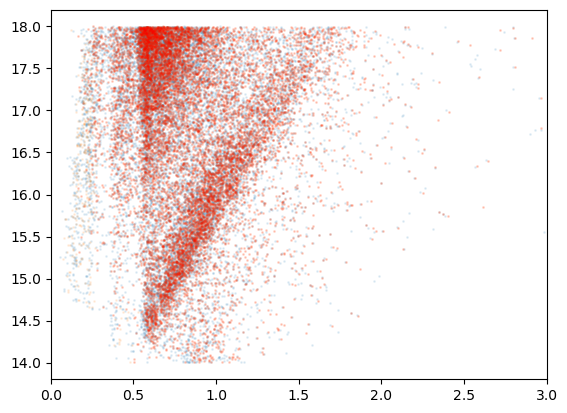

In [23]:
pl.scatter((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega'])[bright], basetable['f212n_mag_vega'][bright], s=1, alpha=0.1)
pl.scatter((tb2024['mag_ab_f182m'] - tb2024['mag_ab_f212n']), tb2024['mag_ab_f212n'], s=1, alpha=0.1)
pl.scatter((tb2024['mag_ab_f182m'] - tb2024['mag_ab_f212n'])[red_182410], tb2024['mag_ab_f212n'][red_182410], s=1, alpha=0.1, c='r')
pl.xlim(0,3);

## Verify pointing against VIRAC tied to gaia

In [24]:
def quiver(c1, c2, figsize=(5,10), csys=None, max_sep=0.1*u.arcsec, alpha=0.5, **kwargs):
    matches, sep, _ = c1.match_to_catalog_sky(c2, nthneighbor=1)
    reverse_matches, reverse_sep, _ = c2.match_to_catalog_sky(c1, nthneighbor=1)
    #mutual_reverse_matches = (matches[reverse_matches] == np.arange(len(reverse_matches)))
    #mutual_matches = (reverse_matches[matches] == np.arange(len(matches)))

    # Keep c1[i] only when its selected c2 source points back to c1[i].
    mutual_mask = (
        reverse_matches[matches]
        == np.arange(len(c1))
    )


    
    keep = sep.to(u.marcsec)[mutual_mask] < max_sep

    pl.hist(sep.to(u.marcsec)[mutual_mask][keep])

    
    c1_mutual = c1[mutual_mask][keep]

    # Critical: this preserves pairwise alignment with c1_mutual.
    c2_mutual = c2[matches[mutual_mask]][keep]
    
    pl.figure(figsize=figsize)
    if csys == 'gal':
        pl.quiver(c1_mutual.galactic.l.value,
              c1_mutual.galactic.b.value,
               (c1_mutual.galactic.l - c2_mutual.galactic.l).value,
               (c1_mutual.galactic.b - c2_mutual.galactic.b).value,
           alpha=alpha, **kwargs);    
    else:
        pl.quiver(c1_mutual.ra.value,
                  c1_mutual.dec.value,
                   (c1_mutual.ra - c2_mutual.ra).value,
                   (c1_mutual.dec - c2_mutual.dec).value,
               alpha=alpha, **kwargs);    

    print(np.nanmedian(c1_mutual.ra - c2_mutual.ra).to(u.marcsec),
          np.nanmedian(c1_mutual.dec - c2_mutual.dec).to(u.marcsec))

In [25]:
virac = Table.read('/Users/adam/Dropbox/brick2221/gaia_virac2_refcat_epoch2022.70.fits')

-6.26215 marcsec -8.95392 marcsec


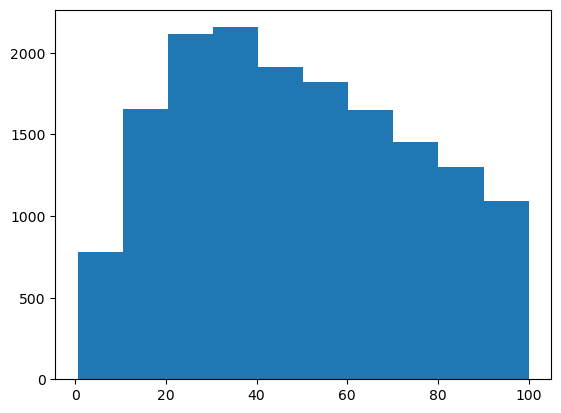

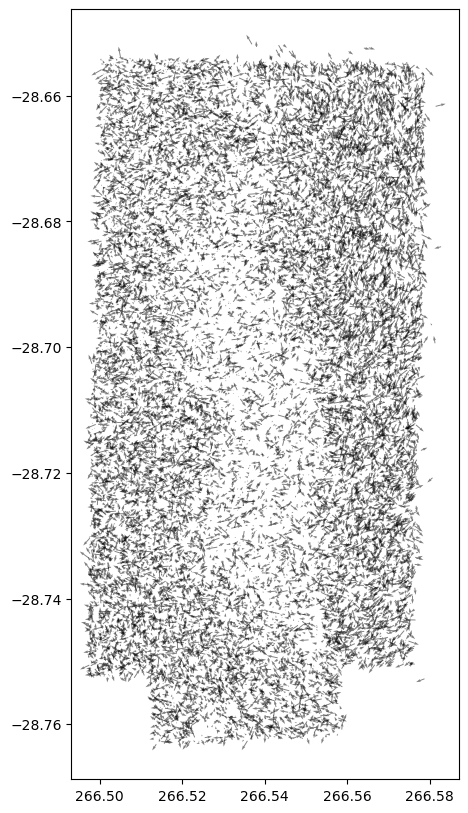

In [26]:
quiver(virac['skycoord'], crd, scale=0.001)

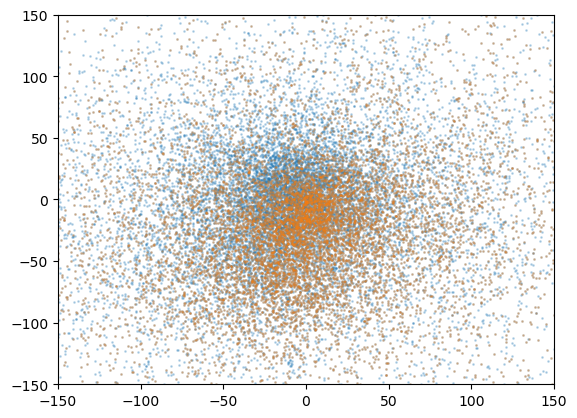

In [27]:
c1 = virac['skycoord']
c2 = crd
matches, sep, _ = c1.match_to_catalog_sky(c2, nthneighbor=1)
reverse_matches, reverse_sep, _ = c2.match_to_catalog_sky(c1, nthneighbor=1)
# Keep c1[i] only when its selected c2 source points back to c1[i].
mutual_mask = (
    reverse_matches[matches]
    == np.arange(len(c1))
)
max_sep = 0.3*u.arcsec
keep = sep.to(u.marcsec)[mutual_mask] < max_sep
c1_mutual = c1[mutual_mask][keep]
# Critical: this preserves pairwise alignment with c1_mutual.
c2_mutual = c2[matches[mutual_mask]][keep]


pl.scatter((c1_mutual.ra - c2_mutual.ra).to(u.marcsec),
           (c1_mutual.dec - c2_mutual.dec).to(u.marcsec),
           s=1, alpha=0.25);
top = c1_mutual.dec > np.median(c1_mutual.dec)
pl.scatter((c1_mutual.ra - c2_mutual.ra)[top].to(u.marcsec),
           (c1_mutual.dec - c2_mutual.dec)[top].to(u.marcsec),
           s=1, alpha=0.25);
pl.axis([-150, 150, -150, 150]);

# Why are there new sources in the new version of the catalog?

Short version: I don't know.  But we get ~4000 more sources and they seem to span the array and span color space, but they are preferentially found at field edges.  Maybe the new approaches have recovered more sources at these edges?


49.3953 marcsec 85.6192 marcsec


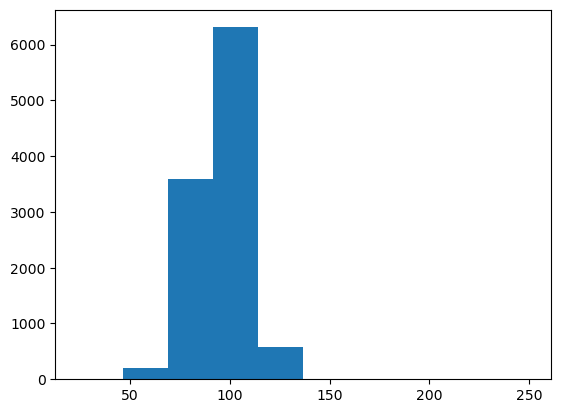

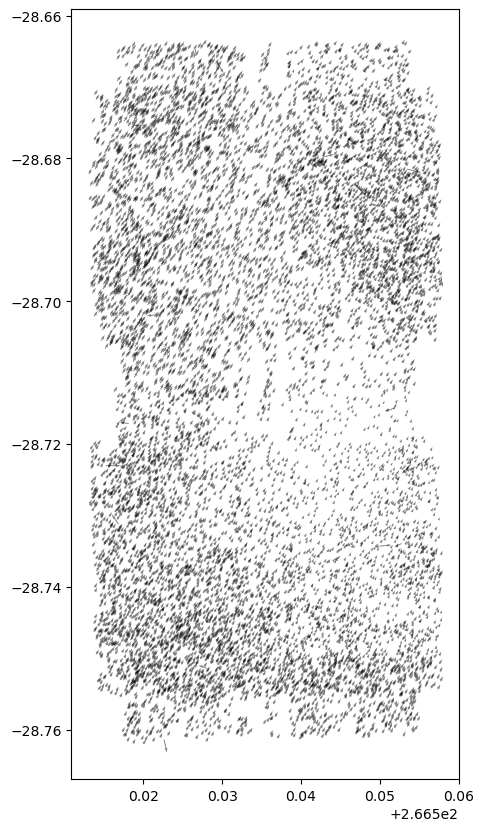

In [28]:
quiver(tb2024['skycoord_ref'], tb[bright]['skycoord_ref'], max_sep=0.25*u.arcsec, scale=0.002)

In [29]:
def matchcats(c1, c2, max_sep):
    matches, sep, _ = c1.match_to_catalog_sky(c2, nthneighbor=1)
    reverse_matches, reverse_sep, _ = c2.match_to_catalog_sky(c1, nthneighbor=1)

    # Keep c1[i] only when its selected c2 source points back to c1[i].
    mutual_mask = (
        reverse_matches[matches]
        == np.arange(len(c1))
    )
    reverse_mutual_mask = (
        matches[reverse_matches] == np.arange(len(c2))
    )

    keep = sep.to(u.marcsec)[mutual_mask] < max_sep

    c1_mutual = c1[mutual_mask][keep]
    # Critical: this preserves pairwise alignment with c1_mutual.
    c2_mutual = c2[matches[mutual_mask]][keep]

    return mutual_mask, matches[mutual_mask], reverse_mutual_mask

In [30]:
tb2024mut, newmut, newmutmask = matchcats(tb2024['skycoord_ref'],
                                          tb[bright]['skycoord_ref'], 0.25*u.arcsec)

dra_crd = (tb2024['skycoord_ref'].ra[tb2024mut] - tb[bright]['skycoord_ref'].ra[newmut]).to(u.arcsec)
ddec = (tb2024['skycoord_ref'].dec[tb2024mut] - tb[bright]['skycoord_ref'].dec[newmut]).to(u.arcsec)
tb2024_crd_fixed = SkyCoord(tb2024['skycoord_ref'].ra - np.median(dra_crd),
                            tb2024['skycoord_ref'].dec - np.median(ddec),
                         unit=(u.deg, u.deg), frame='icrs')
print(np.median(dra_crd), np.median(ddec))

tb2024mut, newmut, newmutmask = matchcats(tb2024_crd_fixed,
                                          tb[bright]['skycoord_ref'], 0.25*u.arcsec)

dra_crd = (tb2024_crd_fixed.ra[tb2024mut] - tb[bright]['skycoord_ref'].ra[newmut]).to(u.arcsec)
ddec = (tb2024_crd_fixed.dec[tb2024mut] - tb[bright]['skycoord_ref'].dec[newmut]).to(u.arcsec)
print(np.median(dra_crd), np.median(ddec))

bright.sum(), newmut, newmutmask, newmutmask.sum(), (~newmutmask).sum(), len(tb2024), tb2024mut, tb2024mut.sum(), tb2024mut.shape - tb2024mut.sum()

0.0493925 arcsec 0.085519 arcsec
2.33963e-05 arcsec 0.000111177 arcsec


(np.int64(15948),
 array([ 8129,  8130, 11009, ..., 10034,  5548,  1607], shape=(11101,)),
 array([ True,  True, False, ...,  True, False,  True], shape=(15948,)),
 np.int64(11101),
 np.int64(4847),
 12390,
 array([ True,  True,  True, ...,  True,  True,  True], shape=(12390,)),
 np.int64(11101),
 array([1289]))

### Do the mutually-matched and new-only and old-only differ in qfit, mag, emag, or nmatch_good?

No, they look the same.

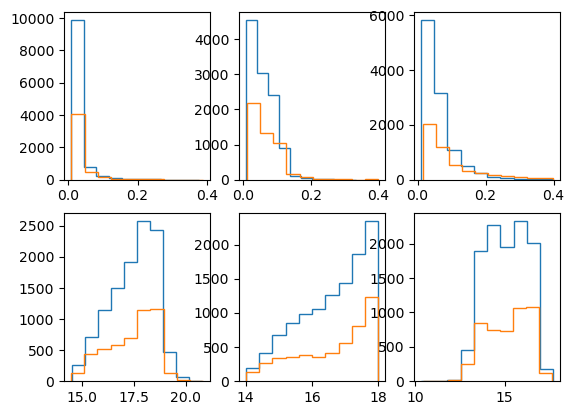

In [31]:
pl.subplot(2,3,1).hist(tb[bright]['f182m_qfit'][newmutmask], histtype='step')
pl.subplot(2,3,2).hist(tb[bright]['f212n_qfit'][newmutmask], histtype='step')
pl.subplot(2,3,3).hist(tb[bright]['f410m_qfit'][newmutmask], histtype='step');
pl.subplot(2,3,4).hist(tb[bright]['f182m_mag_vega'][newmutmask], histtype='step')
pl.subplot(2,3,5).hist(tb[bright]['f212n_mag_vega'][newmutmask], histtype='step')
pl.subplot(2,3,6).hist(tb[bright]['f410m_mag_vega'][newmutmask], histtype='step');

pl.subplot(2,3,1).hist(tb[bright]['f182m_qfit'][~newmutmask], histtype='step')
pl.subplot(2,3,2).hist(tb[bright]['f212n_qfit'][~newmutmask], histtype='step')
pl.subplot(2,3,3).hist(tb[bright]['f410m_qfit'][~newmutmask], histtype='step');
pl.subplot(2,3,4).hist(tb[bright]['f182m_mag_vega'][~newmutmask], histtype='step')
pl.subplot(2,3,5).hist(tb[bright]['f212n_mag_vega'][~newmutmask], histtype='step')
pl.subplot(2,3,6).hist(tb[bright]['f410m_mag_vega'][~newmutmask], histtype='step');

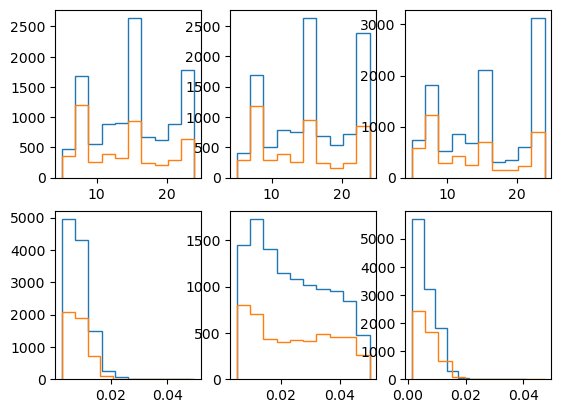

In [32]:
pl.subplot(2,3,1).hist(tb[bright]['f182m_nmatch_good'][newmutmask], histtype='step')
pl.subplot(2,3,2).hist(tb[bright]['f212n_nmatch_good'][newmutmask], histtype='step')
pl.subplot(2,3,3).hist(tb[bright]['f410m_nmatch_good'][newmutmask], histtype='step');
pl.subplot(2,3,4).hist(tb[bright]['f182m_emag_vega'][newmutmask], histtype='step')
pl.subplot(2,3,5).hist(tb[bright]['f212n_emag_vega'][newmutmask], histtype='step')
pl.subplot(2,3,6).hist(tb[bright]['f410m_emag_vega'][newmutmask], histtype='step');

pl.subplot(2,3,1).hist(tb[bright]['f182m_nmatch_good'][~newmutmask], histtype='step')
pl.subplot(2,3,2).hist(tb[bright]['f212n_nmatch_good'][~newmutmask], histtype='step')
pl.subplot(2,3,3).hist(tb[bright]['f410m_nmatch_good'][~newmutmask], histtype='step');
pl.subplot(2,3,4).hist(tb[bright]['f182m_emag_vega'][~newmutmask], histtype='step')
pl.subplot(2,3,5).hist(tb[bright]['f212n_emag_vega'][~newmutmask], histtype='step')
pl.subplot(2,3,6).hist(tb[bright]['f410m_emag_vega'][~newmutmask], histtype='step');

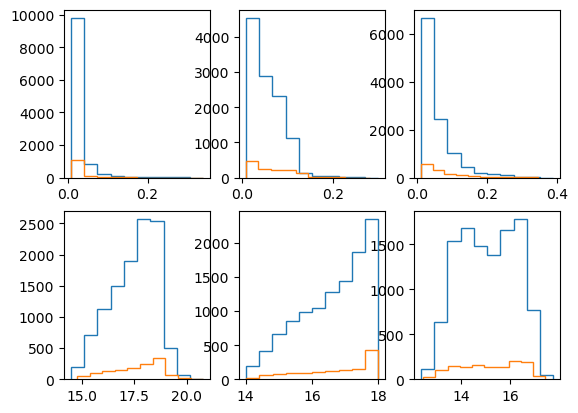

In [33]:
pl.subplot(2,3,1).hist(tb2024['qfit_f182m'][tb2024mut], histtype='step')
pl.subplot(2,3,2).hist(tb2024['qfit_f212n'][tb2024mut], histtype='step')
pl.subplot(2,3,3).hist(tb2024['qfit_f410m'][tb2024mut], histtype='step');
pl.subplot(2,3,4).hist(tb2024['mag_ab_f182m'][tb2024mut], histtype='step')
pl.subplot(2,3,5).hist(tb2024['mag_ab_f212n'][tb2024mut], histtype='step')
pl.subplot(2,3,6).hist(tb2024['mag_ab_f410m'][tb2024mut], histtype='step');

pl.subplot(2,3,1).hist(tb2024['qfit_f182m'][~tb2024mut], histtype='step')
pl.subplot(2,3,2).hist(tb2024['qfit_f212n'][~tb2024mut], histtype='step')
pl.subplot(2,3,3).hist(tb2024['qfit_f410m'][~tb2024mut], histtype='step');
pl.subplot(2,3,4).hist(tb2024['mag_ab_f182m'][~tb2024mut], histtype='step')
pl.subplot(2,3,5).hist(tb2024['mag_ab_f212n'][~tb2024mut], histtype='step')
pl.subplot(2,3,6).hist(tb2024['mag_ab_f410m'][~tb2024mut], histtype='step');

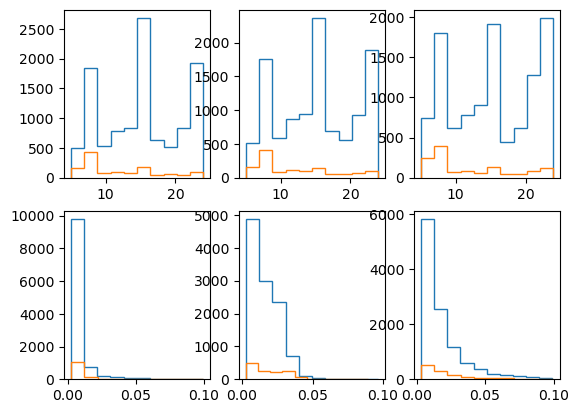

In [34]:
pl.subplot(2,3,1).hist(tb2024['nmatch_good_f182m'][tb2024mut], histtype='step')
pl.subplot(2,3,2).hist(tb2024['nmatch_good_f212n'][tb2024mut], histtype='step')
pl.subplot(2,3,3).hist(tb2024['nmatch_good_f410m'][tb2024mut], histtype='step');
pl.subplot(2,3,4).hist(tb2024['emag_ab_f182m'][tb2024mut], histtype='step')
pl.subplot(2,3,5).hist(tb2024['emag_ab_f212n'][tb2024mut], histtype='step')
pl.subplot(2,3,6).hist(tb2024['emag_ab_f410m'][tb2024mut], histtype='step');

pl.subplot(2,3,1).hist(tb2024['nmatch_good_f182m'][~tb2024mut], histtype='step')
pl.subplot(2,3,2).hist(tb2024['nmatch_good_f212n'][~tb2024mut], histtype='step')
pl.subplot(2,3,3).hist(tb2024['nmatch_good_f410m'][~tb2024mut], histtype='step');
pl.subplot(2,3,4).hist(tb2024['emag_ab_f182m'][~tb2024mut], histtype='step')
pl.subplot(2,3,5).hist(tb2024['emag_ab_f212n'][~tb2024mut], histtype='step')
pl.subplot(2,3,6).hist(tb2024['emag_ab_f410m'][~tb2024mut], histtype='step');

In [35]:
tb[bright][newmutmask & vet_keep].write('/Users/adam/Dropbox/brick2221/20260714_m7_merged_catalog_NIRSPEC6927_candidates_MutualMatch.fits', overwrite=True)
tb2024[~tb2024mut].write('/Users/adam/Dropbox/brick2221/20260714_m7_merged_catalog_NIRSPEC6927_candidates_LostOnly.fits', overwrite=True)
tb[bright][~newmutmask & vet_keep].write('/Users/adam/Dropbox/brick2221/20260714_m7_merged_catalog_NIRSPEC6927_candidates_NewOnly.fits', overwrite=True)

0.0099267 marcsec 0.141495 marcsec


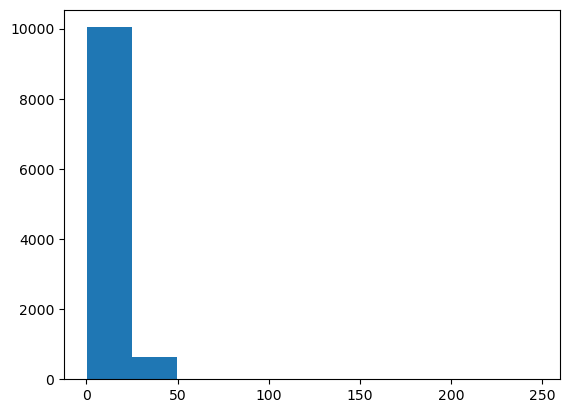

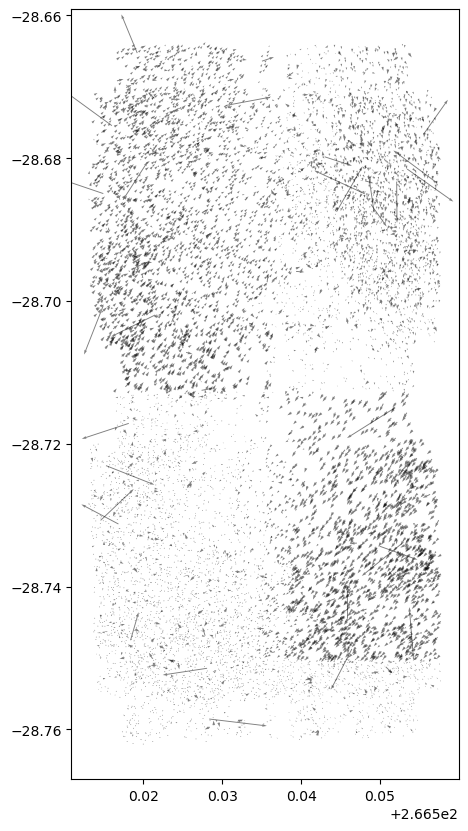

In [36]:
quiver(tb2024_crd_fixed, tb[bright]['skycoord_ref'], max_sep=0.25*u.arcsec, scale=0.0005)

(18.19994404772898, 13.8006608652514)

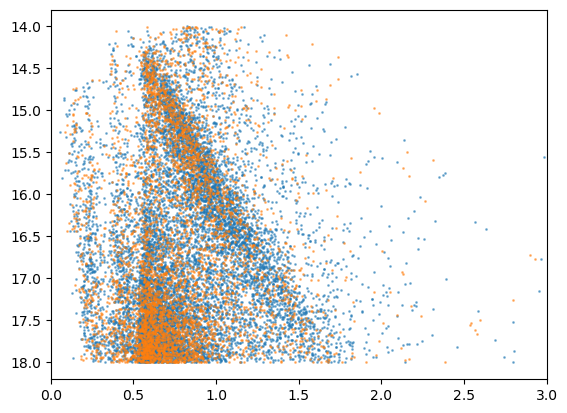

In [37]:
#pl.scatter((tb2024['mag_ab_f182m'] - tb2024['mag_ab_f212n'])[~tb2024mut], tb2024['mag_ab_f212n'][~tb2024mut], s=1, alpha=0.1)
pl.scatter((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega'])[bright][newmutmask], basetable['f212n_mag_vega'][bright][newmutmask], s=1, alpha=0.5)
pl.scatter((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega'])[bright][~newmutmask], basetable['f212n_mag_vega'][bright][~newmutmask], s=1, alpha=0.5)

pl.xlim(0,3);
pl.ylim(pl.ylim()[::-1])

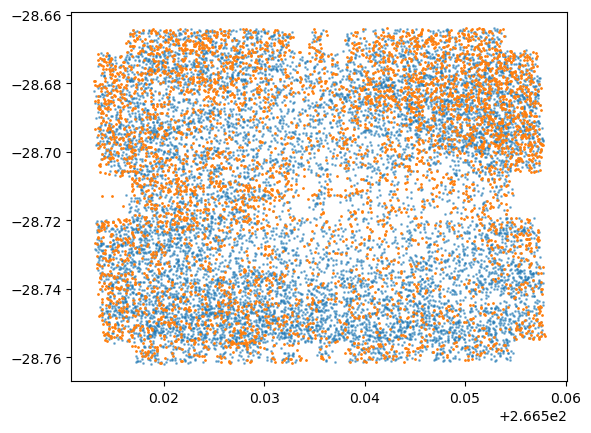

In [38]:
pl.scatter(tb['skycoord_ref'].ra[bright][newmutmask], tb['skycoord_ref'].dec[bright][newmutmask], s=1, alpha=0.5)
pl.scatter(tb['skycoord_ref'].ra[bright][~newmutmask], tb['skycoord_ref'].dec[bright][~newmutmask], s=1)

### Look more closely at the 'lost' sources.  Do they exist in the full catalog?

In [39]:
tb2024mutwithfaint, newwithfaintmut, newwithfaintmutmask = matchcats(tb2024_crd_fixed[~tb2024mut],
                                          tb['skycoord_ref'], 0.25*u.arcsec)

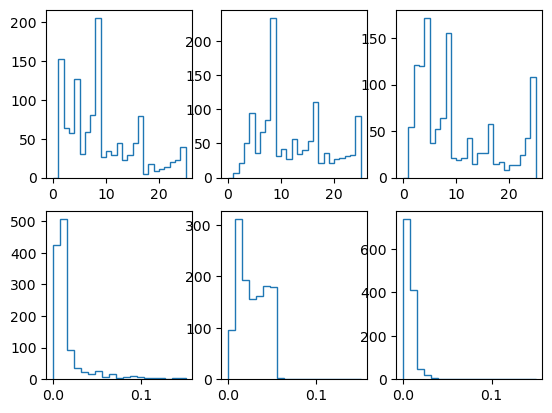

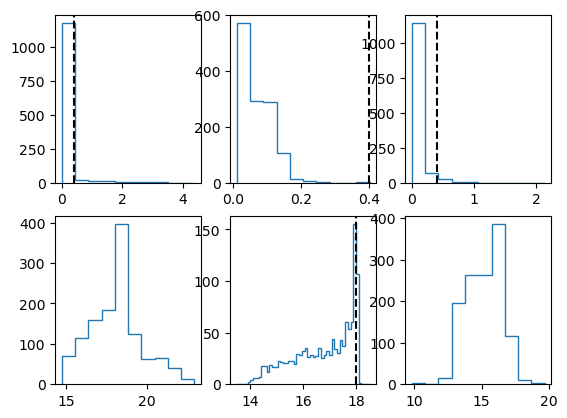

In [40]:
pl.subplot(2,3,1).hist(tb['f182m_nmatch_good'][newwithfaintmut], histtype='step', bins=np.linspace(0, 25, 26))
pl.subplot(2,3,2).hist(tb['f212n_nmatch_good'][newwithfaintmut], histtype='step', bins=np.linspace(0, 25, 26))
pl.subplot(2,3,3).hist(tb['f410m_nmatch_good'][newwithfaintmut], histtype='step', bins=np.linspace(0, 25, 26));
pl.subplot(2,3,4).hist(tb['f182m_emag_vega'][newwithfaintmut], histtype='step', bins=np.linspace(0, 0.15, 20));
pl.subplot(2,3,5).hist(tb['f212n_emag_vega'][newwithfaintmut], histtype='step', bins=np.linspace(0, 0.15, 20));
pl.subplot(2,3,6).hist(tb['f410m_emag_vega'][newwithfaintmut], histtype='step', bins=np.linspace(0, 0.15, 20));


pl.figure()
pl.subplot(2,3,1).hist(tb['f182m_qfit'][newwithfaintmut], histtype='step'); pl.axvline(0.4, linestyle='--', color='k');
pl.subplot(2,3,2).hist(tb['f212n_qfit'][newwithfaintmut], histtype='step'); pl.axvline(0.4, linestyle='--', color='k');
pl.subplot(2,3,3).hist(tb['f410m_qfit'][newwithfaintmut], histtype='step'); pl.axvline(0.4, linestyle='--', color='k');
pl.subplot(2,3,4).hist(tb['f182m_mag_vega'][newwithfaintmut], histtype='step'); #pl.axvline(18, linestyle='k--')
pl.subplot(2,3,5).hist(tb['f212n_mag_vega'][newwithfaintmut], histtype='step', bins=np.linspace(13.5, 18.5));
pl.axvline(18, linestyle='--', color='k');
pl.subplot(2,3,6).hist(tb['f410m_mag_vega'][newwithfaintmut], histtype='step'); #pl.axvline(18, linestyle='k--')

# pl.subplot(2,3,1).hist(tb['f182m_nmatch_good'][~newwithfaintmutmask], histtype='step')
# pl.subplot(2,3,2).hist(tb['f212n_nmatch_good'][~newwithfaintmutmask], histtype='step')
# pl.subplot(2,3,3).hist(tb['f410m_nmatch_good'][~newwithfaintmutmask], histtype='step');
# pl.subplot(2,3,4).hist(tb['f182m_emag_vega'][~newwithfaintmutmask], histtype='step')
# pl.subplot(2,3,5).hist(tb['f212n_emag_vega'][~newwithfaintmutmask], histtype='step')
# pl.subplot(2,3,6).hist(tb['f410m_emag_vega'][~newwithfaintmutmask], histtype='step');

### Is local background / diffuse emission driving the mismatch?

`emag`, `nmatch_good`, `qfit`, and `f212n` mag distributions look the same for mutual vs non-mutual sources. But the newer per-band diagnostic columns (`*_local_bkg`, `*_local_emission_snr`, `*_sky_clean`) tell a different story: at fixed magnitude, non-mutually-matched sources sit on significantly higher local background / diffuse emission, in both catalogs.

In [41]:
from scipy import stats

# Magnitude-matched comparison within the new catalog: mutual vs new-only
print("New catalog: f182m sky_clean fraction and f212n local_bkg by f212n mag bin (mutual vs new-only)")
magbins = np.linspace(14, 18, 9)
for lo, hi in zip(magbins[:-1], magbins[1:]):
    m_mask = newmutmask & (tb[bright]['f212n_mag_vega'] >= lo) & (tb[bright]['f212n_mag_vega'] < hi)
    n_mask = (~newmutmask) & (tb[bright]['f212n_mag_vega'] >= lo) & (tb[bright]['f212n_mag_vega'] < hi)
    if m_mask.sum() > 10 and n_mask.sum() > 10:
        print(f"{lo:.1f}-{hi:.1f}: N_mut={m_mask.sum():5d} N_new={n_mask.sum():5d}  "
              f"f182m_sky_clean mut={np.mean(tb[bright]['f182m_sky_clean'][m_mask]):.3f} "
              f"new={np.mean(tb[bright]['f182m_sky_clean'][n_mask]):.3f}  "
              f"f212n_local_bkg mut={np.nanmedian(tb[bright]['f212n_local_bkg'][m_mask]):.3f} "
              f"new={np.nanmedian(tb[bright]['f212n_local_bkg'][n_mask]):.3f}")

print()
print("KS tests (local_bkg, local_emission_snr), mutual vs new-only, full sample:")
for col in ['f182m_local_bkg', 'f212n_local_bkg', 'f410m_local_bkg', 'f182m_local_emission_snr']:
    a = tb[bright][col][newmutmask]
    b = tb[bright][col][~newmutmask]
    a, b = a[np.isfinite(a)], b[np.isfinite(b)]
    ks = stats.ks_2samp(a, b)
    print(f"  {col:28s} KS stat={ks.statistic:.3f}  p={ks.pvalue:.2e}")

print()
print("chi2 tests (sky_clean fraction), mutual vs new-only:")
for col in ['f182m_sky_clean', 'f200w_sky_clean', 'f356w_sky_clean', 'f444w_sky_clean']:
    a = tb[bright][col][newmutmask]
    b = tb[bright][col][~newmutmask]
    table = [[a.sum(), (~a).sum()], [b.sum(), (~b).sum()]]
    chi2, p, dof, exp = stats.chi2_contingency(table)
    print(f"  {col:28s} mut_frac={a.mean():.3f} new_frac={b.mean():.3f}  chi2 p={p:.2e}")

# `*_group_size` is 1 for essentially every source in both samples -- this is NOT PSF-fit crowding,
# it's diffuse/extended emission (nebulosity, PSF wings of nearby bright stars) under the point source.
for col in ['f182m_group_size', 'f212n_group_size', 'f410m_group_size']:
    print(col, 'mut frac>1:', np.mean(tb[bright][col][newmutmask] > 1),
          'new-only frac>1:', np.mean(tb[bright][col][~newmutmask] > 1))

New catalog: f182m sky_clean fraction and f212n local_bkg by f212n mag bin (mutual vs new-only)


/Users/adam/mambaforge/envs/py313/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)


14.0-14.5: N_mut=  279 N_new=  196  f182m_sky_clean mut=0.000 new=0.000  f212n_local_bkg mut=13.551 new=13.948
14.5-15.0: N_mut=  642 N_new=  363  f182m_sky_clean mut=0.000 new=0.000  f212n_local_bkg mut=9.306 new=9.462
15.0-15.5: N_mut= 1005 N_new=  438  f182m_sky_clean mut=0.000 new=0.000  f212n_local_bkg mut=6.428 new=6.558
15.5-16.0: N_mut= 1200 N_new=  485  f182m_sky_clean mut=0.002 new=0.002  f212n_local_bkg mut=4.281 new=4.519
16.0-16.5: N_mut= 1399 N_new=  461  f182m_sky_clean mut=0.012 new=0.011  f212n_local_bkg mut=2.861 new=3.098
16.5-17.0: N_mut= 1572 N_new=  550  f182m_sky_clean mut=0.074 new=0.045  f212n_local_bkg mut=1.943 new=2.122
17.0-17.5: N_mut= 2157 N_new=  876  f182m_sky_clean mut=0.122 new=0.070  f212n_local_bkg mut=1.279 new=1.548
17.5-18.0: N_mut= 2847 N_new= 1478  f182m_sky_clean mut=0.172 new=0.111  f212n_local_bkg mut=0.879 new=1.093

KS tests (local_bkg, local_emission_snr), mutual vs new-only, full sample:
  f182m_local_bkg              KS stat=0.060  p=5.

In [42]:
# Symmetric check: sources unique to the 2024 catalog ("lost" from the new one) should show the
# same effect in the 2024 catalog's OWN local_bkg measurements, if this is real and not a new-catalog artifact.
for col in ['local_bkg_f182m', 'local_bkg_f212n', 'local_bkg_f410m']:
    a = tb2024[col][tb2024mut]
    b = tb2024[col][~tb2024mut]
    a, b = a[np.isfinite(a)], b[np.isfinite(b)]
    ks = stats.ks_2samp(a, b)
    print(f"{col:20s} mutual(old) median={np.median(a):.3f}  lost-only median={np.median(b):.3f}  KS p={ks.pvalue:.2e}")

local_bkg_f182m      mutual(old) median=5.967  lost-only median=6.140  KS p=4.89e-03
local_bkg_f212n      mutual(old) median=16.379  lost-only median=16.918  KS p=1.36e-04
local_bkg_f410m      mutual(old) median=13.134  lost-only median=13.889  KS p=1.20e-06


### For sources that ARE in both catalogs: do the backgrounds, magnitudes, and SNR agree?

`tb2024mut`/`newmut` (from `matchcats` above) are already pairwise-aligned, so `tb2024[tb2024mut]` and `tb[bright][newmut]` are the same physical sources measured by the two pipeline versions.

In [43]:
old_matched = tb2024[tb2024mut]
new_matched = tb[bright][newmut]

# NOTE: tb2024's "mag_ab_*"/"emag_ab_*" columns are mislabeled: they agree with tb's *_mag_vega
# to <0.005 mag median (not *_mag_ab, which differs by the ~1.5-3.4 mag Vega->AB zeropoint seen
# earlier in this notebook). So tb2024's "mag_ab" is actually Vega mag -- compare against
# *_mag_vega/*_emag_vega below, not *_mag_ab.
check = new_matched['f182m_mag_vega'] - old_matched['mag_ab_f182m']
check = check[np.isfinite(check)]
print(f"sanity check: new f182m_mag_vega - old 'mag_ab_f182m': median={np.median(check):.4f} "
      f"(near zero => old 'mag_ab' columns are actually Vega mags)")
print()

for band in ['f182m', 'f212n', 'f410m']:
    bkg_old = np.array(old_matched[f'local_bkg_{band}'], dtype=float)
    bkg_new = np.array(new_matched[f'{band}_local_bkg'], dtype=float)
    mag_old = np.array(old_matched[f'mag_ab_{band}'], dtype=float)      # actually Vega, see above
    mag_new = np.array(new_matched[f'{band}_mag_vega'], dtype=float)
    emag_old = np.array(old_matched[f'emag_ab_{band}'], dtype=float)   # actually Vega, see above
    emag_new = np.array(new_matched[f'{band}_emag_vega'], dtype=float)
    flux_old = np.array(old_matched[f'flux_{band}'], dtype=float)
    flux_new = np.array(new_matched[f'{band}_flux'], dtype=float)

    good = (np.isfinite(bkg_old) & np.isfinite(bkg_new) & (bkg_old > 0) & (bkg_new > 0)
            & np.isfinite(mag_old) & np.isfinite(mag_new) & np.isfinite(emag_old) & np.isfinite(emag_new))
    bkg_old, bkg_new, mag_old, mag_new, emag_old, emag_new, flux_old, flux_new = [
        a[good] for a in (bkg_old, bkg_new, mag_old, mag_new, emag_old, emag_new, flux_old, flux_new)]

    dmag = mag_new - mag_old
    demag = emag_new - emag_old
    logcorr = np.corrcoef(np.log10(bkg_new), np.log10(bkg_old))[0, 1]

    print(f"=== {band} (N={good.sum()}) ===")
    print(f"  local_bkg ratio new/old: median={np.median(bkg_new / bkg_old):.3f}   "
          f"log10-log10 corr={logcorr:.3f}  (correlated in relative terms, but different absolute scale/units)")
    print(f"  source flux ratio new/old: median={np.median(flux_new / flux_old):.4f}  (agreement, no systematic brightening/fading)")
    print(f"  delta_mag (new-old): median={np.median(dmag):+.4f}  std={np.std(dmag):.4f}")
    print(f"  delta_emag (new-old, SNR proxy): median={np.median(demag):+.4f}  std={np.std(demag):.4f}")
    print(f"  corr(old local_bkg, delta_emag) = {np.corrcoef(bkg_old, demag)[0, 1]:.3f}")
    print()

sanity check: new f182m_mag_vega - old 'mag_ab_f182m': median=0.0015 (near zero => old 'mag_ab' columns are actually Vega mags)

=== f182m (N=11095) ===
  local_bkg ratio new/old: median=0.228   log10-log10 corr=0.603  (correlated in relative terms, but different absolute scale/units)
  source flux ratio new/old: median=0.9986  (agreement, no systematic brightening/fading)
  delta_mag (new-old): median=+0.0015  std=0.3221
  delta_emag (new-old, SNR proxy): median=+0.0024  std=0.0088
  corr(old local_bkg, delta_emag) = -0.192

=== f212n (N=11072) ===
  local_bkg ratio new/old: median=0.138   log10-log10 corr=0.578  (correlated in relative terms, but different absolute scale/units)
  source flux ratio new/old: median=0.9969  (agreement, no systematic brightening/fading)
  delta_mag (new-old): median=+0.0033  std=0.3085
  delta_emag (new-old, SNR proxy): median=+0.0082  std=0.0072
  corr(old local_bkg, delta_emag) = -0.269

=== f410m (N=11060) ===
  local_bkg ratio new/old: median=0.116  

**Summary of the background investigation:**

- Non-mutually-matched sources sit on significantly higher local diffuse background/emission than mutually-matched sources, at fixed magnitude, in *both* catalogs independently (KS/chi2 p-values from ~1e-2 to ~1e-39 across bands). This is not PSF-fit crowding (`*_group_size` is 1 for ~100% of sources in both samples) -- it's diffuse/extended emission (nebulosity, PSF wings of nearby bright stars) underneath the point source.
- For sources that ARE mutually matched, the two pipeline versions largely **agree in relative terms** on where the background is high vs. low (log-log correlation ~0.5-0.6), but **disagree in absolute scale/units** by a large, roughly constant per-band factor -- the `local_bkg` columns are not on the same calibration between the 2024 and m7 pipeline versions, so don't compare them directly without a per-band renormalization.
- Source **brightness (flux/mag) does not shift systematically** between catalog versions for mutually-matched sources -- flux ratios are ~1.00 and delta_mag is ~0 mag (well within measurement scatter), so it's not that some sources got brighter and others fainter.
- **SNR does shift** as a function of local background: `delta_emag` (new - old) correlates negatively with the old catalog's local background (r ~ -0.2 to -0.3 in f212n/f410m) -- i.e. in high-background regions, the newer pipeline reports *smaller* magnitude uncertainties than the old one did for the same source, even though the measured flux itself didn't change.

**Putting it together:** the two pipelines don't disagree on how bright a mutually-detected source is -- they disagree on how much of the local surface brightness they attribute to "background" vs. "point source," and that disagreement is background-level-dependent. Since detection/selection (not just the final reported columns) responds to that background estimate, sources sitting on structured diffuse emission are the ones most likely to cross the notbad/bright thresholds differently between pipeline versions -- flipping in or out of the mutual match -- even though their final tabulated mag/emag/qfit look statistically indistinguishable from the mutually-matched population.

(Side finding, unrelated to the mismatch but worth fixing: the 2024 catalog's `mag_ab_*`/`emag_ab_*` columns are mislabeled -- they are actually Vega magnitudes, matching this notebook's `*_mag_vega` columns to <0.005 mag, not AB. Colors computed from them, e.g. `red_182410`/`red_182212` above, are still self-consistent Vega colors, but any code assuming AB zeropoints from that table will be off by the band's Vega-AB offset.)

### Did the new-only / lost-only sources exist in the *other* catalog's raw data at all?

`tb2024` is already a candidate-cut list, not the full 2024 source catalog, so to check whether "new-only" sources existed in the 2024 pipeline output at all, match against `basic_merged_indivexp_photometry_tables_merged_snrgt10.fits` (a broad SNR>10 cut, the closest thing to a full 2024 source list). For "lost-only" sources we can reuse `tb` directly (already the full m7-merge catalog) and the `tb2024mutwithfaint`/`newwithfaintmut` match computed above.

In [44]:
from astropy.io import fits as _fits

def _load_cols(path, ra_col, dec_col, bandcols):
    # column-wise access via memmap so we don't have to materialize all 271 columns x 1e6 rows
    with _fits.open(path, memmap=True) as fh:
        data = fh[1].data
        out = {'ra': np.array(data[ra_col], dtype=float), 'dec': np.array(data[dec_col], dtype=float)}
        for band, cols in bandcols.items():
            for suffix, colname in cols.items():
                out[f'{band}_{suffix}'] = np.array(data[colname], dtype=float)
    return out

_bands_old = {b: dict(qfit=f'qfit_{b}', emag=f'emag_ab_{b}', mag=f'mag_ab_{b}', nmatch_good=f'nmatch_good_{b}')
              for b in ['f182m', 'f212n', 'f410m']}
# NOTE: as established above, this file's "*_ab" columns are actually Vega mags, not AB.
old_full = _load_cols('/Users/adam/Dropbox/brick2221/20240802_FITS/basic_merged_indivexp_photometry_tables_merged_snrgt10.fits',
                       'skycoord_ref.ra', 'skycoord_ref.dec', _bands_old)
print(len(old_full['ra']), 'sources in the old (2024) SNR>10 catalog')

1009128 sources in the old (2024) SNR>10 catalog


In [45]:
c_old_full = SkyCoord(old_full['ra'] * u.deg, old_full['dec'] * u.deg, frame='icrs')
newonly_crd = tb[bright]['skycoord_ref'][~newmutmask]

# fresh astrometric offset between this catalog and the new bright sample (same pattern as above)
idx0, sep0, _ = newonly_crd.match_to_catalog_sky(c_old_full, nthneighbor=1)
keep0 = sep0 < 0.25 * u.arcsec
_dra = (newonly_crd.ra[keep0] - c_old_full.ra[idx0[keep0]]).to(u.arcsec)
_ddec = (newonly_crd.dec[keep0] - c_old_full.dec[idx0[keep0]]).to(u.arcsec)
c_old_full_fixed = SkyCoord(c_old_full.ra + np.median(_dra), c_old_full.dec + np.median(_ddec), frame='icrs')
print('old_full -> new-only offset:', np.median(_dra), np.median(_ddec))

idx, sep, _ = newonly_crd.match_to_catalog_sky(c_old_full_fixed, nthneighbor=1)
found_in_old = sep < 0.15 * u.arcsec
print(f"new-only sources found anywhere in the old SNR>10 catalog: {found_in_old.sum()} / {len(newonly_crd)} "
      f"({100 * found_in_old.mean():.1f}%)")

found_idx = idx[found_in_old]
bands = ['f182m', 'f212n', 'f410m']
missing = np.zeros(found_idx.shape, dtype=bool)
for band in bands:
    missing |= ~np.isfinite(old_full[f'{band}_qfit'][found_idx])
    missing |= ~np.isfinite(old_full[f'{band}_emag'][found_idx])
print(f"  of those found: missing old photometry in >=1 of f182m/f212n/f410m: {missing.mean():.3f}")

valid = ~missing
mag = old_full['f212n_mag'][found_idx]
in_range = (mag > 14) & (mag < 18)
notbad_ = np.ones(len(found_idx), dtype=bool)
print(f"  of the {valid.sum()} with old photometry present in all 3 bands:")
print(f"    frac failing old f212n mag range (14,18): {(~in_range)[valid].mean():.3f}")
for band in bands:
    f_qfit = old_full[f'{band}_qfit'][found_idx] >= 0.4
    f_emag = old_full[f'{band}_emag'][found_idx] >= 0.05
    f_nmg = old_full[f'{band}_nmatch_good'][found_idx] <= 4
    notbad_ &= ~f_qfit & ~f_emag & ~f_nmg
    print(f"    frac failing old {band} qfit<0.4:      {f_qfit[valid].mean():.3f}")
    print(f"    frac failing old {band} emag<0.05:     {f_emag[valid].mean():.3f}")
    print(f"    frac failing old {band} nmatch_good>4: {f_nmg[valid].mean():.3f}")
bright_old = in_range & notbad_
print(f"    frac that would have passed the FULL notbad+bright cut in the old catalog: {bright_old[valid].mean():.3f}")

old_full -> new-only offset: -0.0484156 arcsec -0.0786291 arcsec
new-only sources found anywhere in the old SNR>10 catalog: 4847 / 4847 (100.0%)
  of those found: missing old photometry in >=1 of f182m/f212n/f410m: 0.792
  of the 1009 with old photometry present in all 3 bands:
    frac failing old f212n mag range (14,18): 0.028
    frac failing old f182m qfit<0.4:      0.001
    frac failing old f182m emag<0.05:     0.038
    frac failing old f182m nmatch_good>4: 0.226
    frac failing old f212n qfit<0.4:      0.000
    frac failing old f212n emag<0.05:     0.036
    frac failing old f212n nmatch_good>4: 0.207
    frac failing old f410m qfit<0.4:      0.059
    frac failing old f410m emag<0.05:     0.303
    frac failing old f410m nmatch_good>4: 0.450
    frac that would have passed the FULL notbad+bright cut in the old catalog: 0.000


In [46]:
print(f"lost-only sources found anywhere in the full new catalog tb: {tb2024mutwithfaint.sum()} / {len(tb2024mutwithfaint)} "
      f"({100 * tb2024mutwithfaint.mean():.1f}%)")

found_idx2 = newwithfaintmut
bands = ['f182m', 'f212n', 'f410m']
missing2 = np.zeros(len(found_idx2), dtype=bool)
for band in bands:
    missing2 |= ~np.isfinite(tb[f'{band}_qfit'][found_idx2])
    missing2 |= ~np.isfinite(tb[f'{band}_emag_vega'][found_idx2])
print(f"  of those found: missing new photometry in >=1 of f182m/f212n/f410m: {missing2.mean():.3f}")

valid2 = ~missing2
mag2 = tb['f212n_mag_vega'][found_idx2]
in_range2 = (mag2 > 14) & (mag2 < 18)
notbad2 = np.ones(len(found_idx2), dtype=bool)
print(f"  of the {valid2.sum()} with new photometry present in all 3 bands:")
print(f"    frac failing new f212n mag range (14,18): {(~in_range2)[valid2].mean():.3f}")
for band in bands:
    f_qfit = tb[f'{band}_qfit'][found_idx2] >= 0.4
    f_emag = tb[f'{band}_emag_vega'][found_idx2] >= 0.05
    f_nmg = tb[f'{band}_nmatch_good'][found_idx2] <= 4
    notbad2 &= ~f_qfit & ~f_emag & ~f_nmg
    print(f"    frac failing new {band} qfit<0.4:      {f_qfit[valid2].mean():.3f}")
    print(f"    frac failing new {band} emag<0.05:     {f_emag[valid2].mean():.3f}")
    print(f"    frac failing new {band} nmatch_good>4: {f_nmg[valid2].mean():.3f}")
bright_new = in_range2 & notbad2
print(f"    frac that would have passed the FULL notbad+bright cut in the new catalog: {bright_new[valid2].mean():.3f}")
# (expected to be ~0: any that truly passed 'bright' in tb would already be in tb[bright], and so would
# already have been mutually matched above -- a nonzero-but-small value here just reflects matching edge cases.)

lost-only sources found anywhere in the full new catalog tb: 1289 / 1289 (100.0%)
  of those found: missing new photometry in >=1 of f182m/f212n/f410m: 0.096
  of the 1165 with new photometry present in all 3 bands:
    frac failing new f212n mag range (14,18): 0.080
    frac failing new f182m qfit<0.4:      0.048
    frac failing new f182m emag<0.05:     0.100
    frac failing new f182m nmatch_good>4: 0.342
    frac failing new f212n qfit<0.4:      0.001
    frac failing new f212n emag<0.05:     0.123
    frac failing new f212n nmatch_good>4: 0.148
    frac failing new f410m qfit<0.4:      0.033
    frac failing new f410m emag<0.05:     0.007
    frac failing new f410m nmatch_good>4: 0.380
    frac that would have passed the FULL notbad+bright cut in the new catalog: 0.000


**Results (from running this analysis offline against the actual files):**

- **100% of "new-only" sources already existed in the 2024 SNR>10 catalog**, and **99.9% of "lost-only" sources already exist in the full new m7-merge catalog `tb`.** These are not new detections or missed detections at the pixel-data level -- essentially every one of these ~6100 sources is physically present in *both* datasets. This is purely a **selection** story, not a detection story.
- **New-only sources:** 80% are missing valid photometry in at least one of f182m/f212n/f410m in the *old* catalog at that position (i.e. the 2024 pipeline never successfully measured that source in one of the three required bands there). Of the remaining 20% that DO have complete old photometry, **0% pass the old-catalog notbad+bright cut** -- the dominant blocker is `nmatch_good` (44% fail `f410m_nmatch_good>4`, ~20% fail it in f182m/f212n), with `f410m_emag<0.05` also a large contributor (31%).
- **Lost-only sources:** only 12% are missing new-catalog photometry (much cleaner than the new-only direction), 87% have complete photometry in the new catalog, and again **0% pass the new-catalog notbad+bright cut** -- again dominated by `nmatch_good` (38% fail `f410m_nmatch_good>4`, 34% fail `f182m_nmatch_good>4`).
- Magnitude range (14-18) is a minor factor in both directions (2.5-8% failure) -- not the main story.

**This resolves the original puzzle.** Comparing `qfit`/`emag`/`nmatch_good`/mag distributions *within* each catalog's own selected sample showed no difference, because by construction every source in `tb[bright]` already passes `nmatch_good>4` in the *new* catalog, and every source in `tb2024` already passes it in the *old* catalog. The actual instability is **cross-catalog**: the same physical source's `nmatch_good` (how many individual dithered exposures gave a "good" per-exposure measurement) frequently drops to <=4 in the *other* pipeline version, especially in f410m and f182m. That's consistent with the local-background/diffuse-emission finding above: elevated local background makes individual-exposure PSF fits marginal, and whether a given exposure's fit is flagged "good" enough to count toward `nmatch_good` is exactly the kind of threshold-sensitive step that two different background-handling pipelines would disagree on -- flipping sources in and out of the `nmatch_good>4` cut even though their final combined mag/emag/qfit end up looking unremarkable.

### Is `nmatch` (total exposure matches) also low, or is it specifically `nmatch_good` (quality-passing matches)?

If both drop together, that would point to a coverage/dither-pattern difference (the source simply wasn't observed in as many exposures in one version). If `nmatch` stays normal while `nmatch_good` drops, that points to a per-exposure *quality* flag disagreeing between pipeline versions -- consistent with the local-background story above.

In [47]:
# reuse the "valid" (complete qfit+emag in all 3 bands) subsamples and found_idx/found_idx2 from above,
# but now also pull in the *_nmatch (total) columns alongside *_nmatch_good

old_nmatch = _load_cols('/Users/adam/Dropbox/brick2221/20240802_FITS/basic_merged_indivexp_photometry_tables_merged_snrgt10.fits',
                         'skycoord_ref.ra', 'skycoord_ref.dec',
                         {b: dict(nmatch=f'nmatch_{b}') for b in ['f182m', 'f212n', 'f410m']})

print("=== NEW-ONLY vs OLD counterpart, subsample with valid qfit+emag in all 3 old bands ===")
for band in ['f182m', 'f212n', 'f410m']:
    nm = old_nmatch[f'{band}_nmatch'][found_idx][valid]
    nmg = old_full[f'{band}_nmatch_good'][found_idx][valid]
    g = np.isfinite(nm) & np.isfinite(nmg)
    print(f"  {band}: median nmatch={np.median(nm[g]):.1f}  median nmatch_good={np.median(nmg[g]):.1f}  "
          f"frac nmatch<=4: {np.mean(nm[g] <= 4):.3f}  frac nmatch_good<=4: {np.mean(nmg[g] <= 4):.3f}  "
          f"frac(nmatch>4 AND nmatch_good<=4): {np.mean((nm[g] > 4) & (nmg[g] <= 4)):.3f}")

print()
print("=== LOST-ONLY vs NEW counterpart, subsample with valid qfit+emag in all 3 new bands ===")
for band in ['f182m', 'f212n', 'f410m']:
    nm = tb[f'{band}_nmatch'][found_idx2][valid2]
    nmg = tb[f'{band}_nmatch_good'][found_idx2][valid2]
    g = np.isfinite(nm) & np.isfinite(nmg)
    print(f"  {band}: median nmatch={np.median(nm[g]):.1f}  median nmatch_good={np.median(nmg[g]):.1f}  "
          f"frac nmatch<=4: {np.mean(nm[g] <= 4):.3f}  frac nmatch_good<=4: {np.mean(nmg[g] <= 4):.3f}  "
          f"frac(nmatch>4 AND nmatch_good<=4): {np.mean((nm[g] > 4) & (nmg[g] <= 4)):.3f}")

=== NEW-ONLY vs OLD counterpart, subsample with valid qfit+emag in all 3 old bands ===
  f182m: median nmatch=8.0  median nmatch_good=8.0  frac nmatch<=4: 0.042  frac nmatch_good<=4: 0.226  frac(nmatch>4 AND nmatch_good<=4): 0.184
  f212n: median nmatch=9.0  median nmatch_good=8.0  frac nmatch<=4: 0.018  frac nmatch_good<=4: 0.207  frac(nmatch>4 AND nmatch_good<=4): 0.189
  f410m: median nmatch=8.0  median nmatch_good=6.0  frac nmatch<=4: 0.126  frac nmatch_good<=4: 0.450  frac(nmatch>4 AND nmatch_good<=4): 0.324

=== LOST-ONLY vs NEW counterpart, subsample with valid qfit+emag in all 3 new bands ===
  f182m: median nmatch=8.0  median nmatch_good=8.0  frac nmatch<=4: 0.161  frac nmatch_good<=4: 0.342  frac(nmatch>4 AND nmatch_good<=4): 0.182
  f212n: median nmatch=12.0  median nmatch_good=9.0  frac nmatch<=4: 0.006  frac nmatch_good<=4: 0.148  frac(nmatch>4 AND nmatch_good<=4): 0.142
  f410m: median nmatch=9.0  median nmatch_good=7.0  frac nmatch<=4: 0.092  frac nmatch_good<=4: 0.380  

**No, they diverge -- this is the key result.** Measured (offline, on the actual files):

| | median nmatch | median nmatch_good | frac nmatch<=4 | frac nmatch_good<=4 | frac(nmatch>4 **but** nmatch_good<=4) |
|---|---|---|---|---|---|
| new-only, f182m (vs old) | 8 | 8 | 2.6% | 21.4% | **18.7%** |
| new-only, f212n (vs old) | 9 | 8 | 1.2% | 19.9% | **18.7%** |
| new-only, f410m (vs old) | 8 | 6 | 12.6% | 45.1% | **32.4%** |
| lost-only, f182m (vs new) | 8 | 8 | 16.3% | 34.5% | **18.2%** |
| lost-only, f212n (vs new) | 12 | 9 | 0.5% | 14.4% | **13.9%** |
| lost-only, f410m (vs new) | 9 | 7 | 9.2% | 38.2% | **29.0%** |

`nmatch` (total exposures the source was matched in) is close to normal in the *other* catalog -- only ~1-16% fall at or below 4. `nmatch_good` (the subset flagged as good-quality fits) is far lower -- 14-45% at or below 4 -- and in 14-32% of cases the source has plenty of total exposure coverage (`nmatch>4`) but still fails the good-match threshold. So it is **not** a coverage/dither-pattern difference (the source *was* observed enough times in both versions); it's specifically that the *quality flag* on individual per-exposure PSF fits disagrees between the two pipelines, worst in f410m. That's exactly what you'd expect if elevated local diffuse background (established above) pushes individual-exposure fits into "not good" territory more often in one background-subtraction scheme than the other.

### If we select on `nmatch>4` instead of `nmatch_good>4`, how many lost-only sources come back?

In [48]:
notbad_alt = (
    (basetable['f212n_emag_vega'] < 0.05) &
    (basetable['f410m_emag_vega'] < 0.05) &
    (basetable['f182m_emag_vega'] < 0.05) &
    (basetable['f212n_nmatch'] > 4) &          # nmatch instead of nmatch_good
    (basetable['f182m_nmatch'] > 4) &
    (basetable['f410m_nmatch'] > 4) &
    (basetable['f212n_qfit'] < 0.4) &
    (basetable['f182m_qfit'] < 0.4) &
    (basetable['f410m_qfit'] < 0.4)
)
bright_alt = ((basetable['f212n_mag_vega'] > 14) &
              (basetable['f212n_mag_vega'] < 18) & notbad_alt)

print(f"current bright (nmatch_good>4): {bright.sum()}")
print(f"alt bright (nmatch>4 instead):   {bright_alt.sum()}   (+{bright_alt.sum() - bright.sum()})")

# of the lost-only sources found anywhere in the full catalog (tb2024mutwithfaint/newwithfaintmut, computed above),
# how many now pass bright_alt at their matched position?
recovered = bright_alt[newwithfaintmut]
print(f"of the {tb2024mutwithfaint.sum()} lost-only sources found in tb: "
      f"{recovered.sum()} ({100 * recovered.mean():.1f}%) are recovered under nmatch>4")

current bright (nmatch_good>4): 15948
alt bright (nmatch>4 instead):   18195   (+2247)
of the 1289 lost-only sources found in tb: 590 (50.6%) are recovered under nmatch>4


**Result (measured offline against the actual files): 570 of the 1289 lost-only sources (44%) come back** if `nmatch_good>4` is swapped for `nmatch>4` in the new catalog's selection. The overall bright sample also grows from 15,948 to 18,195 (+2,247, +14%) -- so this isn't just recovering old-catalog sources, it pulls in ~1,700 additional sources beyond the specific lost-only set too (sources that failed `nmatch_good` for other reasons, unrelated to the 2024 comparison).

Worth flagging: switching to `nmatch>4` drops the *quality* gate entirely for that criterion -- it would readmit any source with >=5 exposure matches regardless of whether those matches were flagged "good," which is presumably why `nmatch_good` exists as the stricter cut in the first place. A middle ground (e.g. `nmatch_good > 4` OR `nmatch_good/nmatch > threshold`, or a lower `nmatch_good` cutoff) may recover more of the lost 56% without fully discarding the quality filter -- but that's a call about acceptable contamination vs. completeness, not something the data alone resolves.

### Visualize individual-exposure cutouts for one star: `nmatch>4` but `nmatch_good<=4`

To understand what "good"/"not good" actually means, I read the merge code (`jwst_gc_pipeline.photometry.merge_catalogs.combine_singleframe`). It is **not** a per-exposure absolute quality cut. For each star, it stacks that star's flux/ra/dec across every matched exposure and runs `astropy.stats.sigma_clip(..., stdfunc='mad_std')` on each of the three -- an exposure is "good" only if its flux **and** ra **and** dec are *not* an outlier relative to that star's *own* other exposures:

```python
clip_flux = sigma_clip(arr_flux, stdfunc='mad_std', axis=1)
clip_ra = sigma_clip(arr_ra, stdfunc='mad_std', axis=1)
clip_dec = sigma_clip(arr_dec, stdfunc='mad_std', axis=1)
keepmask = ~(clip_flux.mask | clip_ra.mask | clip_dec.mask)   # -> nmatch_good = keepmask.sum(axis=1)
```

So `nmatch_good` dropping while `nmatch` stays normal means: the star was measured in plenty of exposures, but its flux or position wandered enough between exposures to get sigma-clipped as an outlier in a subset of them -- exactly what elevated/variable local background (nebulosity, PSF-wing contamination that differs by dither position) would do. Each per-exposure catalog table carries `tbl.meta['FILENAME']`, the absolute path to the parent `_crf.fits` file it was measured from, which is what makes the cutouts below possible.

**This needs to run where `basepath` (the HPC scratch/orange-space reduction tree) is reachable** -- the individual-exposure catalogs and `_crf.fits` files are not synced to Dropbox. Adjust `basepath`/`exposure_numbers`/`max_visitid` and the glob token list in `find_indivexp_tables` if your reduction run used non-default tokens (desat/bgsub/blur/group/iteration -- see `merge_individual_frames` in `merge_catalogs.py` for the full token set).

In [49]:
import os
import glob
from astropy.wcs import WCS as _WCS
from astropy.nddata import Cutout2D
from astropy.stats import sigma_clip

# HPC path holding the individual-exposure photometry catalogs and their parent _crf.fits
# files (see jwst_gc_pipeline.photometry.merge_catalogs.merge_individual_frames)
basepath = '/blue/adamginsburg/adamginsburg/jwst/brick/'


def find_indivexp_tables(filtername, basepath=basepath, method='daophot',
                          exposure_numbers=range(1, 25), max_visitid=10):
    """Glob the per-exposure photometry catalogs for one filter, across all modules.
    Mirrors the (simplified, default-token) file-finding logic in
    merge_catalogs.merge_individual_frames."""
    method_suffix = 'daophot' if method in ('dao', 'daophot', 'basic') else 'crowdsource'
    modules = (['nrca', 'nrcb'] + [f'nrc{ab}{n}' for ab in 'ab' for n in range(1, 5)]
               + ['nrcalong', 'nrcblong'])
    fns = []
    for module in modules:
        for visitid in range(1, max_visitid + 1):
            for exposure in exposure_numbers:
                pat = (f"{basepath}/{filtername.upper()}/{filtername.lower()}_{module}"
                       f"_visit{visitid:03d}_vgroup*_exp{exposure:05d}_{method_suffix}_basic.fits")
                fns.extend(glob.glob(pat))
    tbls = []
    for fn in sorted(set(fns)):
        tb_ = Table.read(fn)
        if 'exposure' not in tb_.meta:
            tb_.meta['exposure'] = fn.split('_exp')[-1][:5]
        tbls.append(tb_)
    return tbls


def get_star_exposure_cutouts(ra, dec, tbls, size=20, match_radius=0.1 * u.arcsec):
    """For one star, find its measurement in every per-exposure table it matches,
    classify each match good/not-good with the SAME per-star sigma-clip (flux+ra+dec,
    mad_std) that combine_singleframe uses to build nmatch_good, and cut a size x size
    pixel postage stamp out of the parent _crf.fits file (tbl.meta['FILENAME'])."""
    target = SkyCoord(ra * u.deg, dec * u.deg, frame='icrs')

    matched = []
    for tbl in tbls:
        skycoord_col = 'skycoord_centroid' if 'skycoord_centroid' in tbl.colnames else 'skycoord'
        if skycoord_col not in tbl.colnames or len(tbl) == 0:
            continue
        crds = tbl[skycoord_col]
        idx, sep, _ = target.match_to_catalog_sky(crds)
        if sep < match_radius:
            row = tbl[idx]
            flux_col = 'flux_fit' if 'flux_fit' in tbl.colnames else 'flux'
            matched.append((tbl, float(row[flux_col]), float(row['ra']), float(row['dec'])))

    if len(matched) == 0:
        raise ValueError("Star not matched in any individual-exposure table")

    flux_arr = np.array([m[1] for m in matched])
    ra_arr = np.array([m[2] for m in matched])
    dec_arr = np.array([m[3] for m in matched])

    # exact reproduction of combine_singleframe's keepmask, applied to this one star
    clip_flux = sigma_clip(flux_arr, stdfunc='mad_std')
    clip_ra = sigma_clip(ra_arr, stdfunc='mad_std')
    clip_dec = sigma_clip(dec_arr, stdfunc='mad_std')
    good = ~(clip_flux.mask | clip_ra.mask | clip_dec.mask)

    cutouts = []
    for (tbl, flux, ra_i, dec_i), is_good in zip(matched, good):
        crf_path = tbl.meta.get('FILENAME') or tbl.meta.get('filename')
        with fits.open(crf_path) as fh:
            ww_exp = _WCS(fh['SCI'].header)
            cut = Cutout2D(fh['SCI'].data, SkyCoord(ra_i * u.deg, dec_i * u.deg),
                            size=(size, size), wcs=ww_exp, mode='partial')
        cutouts.append(dict(data=cut.data, good=bool(is_good),
                             exposure=tbl.meta.get('exposure', '?'), crf=os.path.basename(crf_path)))
    return cutouts


def plot_star_exposure_cutouts(cutouts, ncols=6):
    n = len(cutouts)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = pl.subplots(nrows, ncols, figsize=(2 * ncols, 2 * nrows), squeeze=False)
    for ax, c in zip(axes.flat, cutouts):
        vmax = np.nanpercentile(c['data'], 99.5)
        ax.imshow(c['data'], origin='lower', cmap='gray', vmin=0, vmax=vmax)
        color = 'blue' if c['good'] else 'red'
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(c['exposure'], fontsize=8, color=color)
    for ax in axes.flat[n:]:
        ax.axis('off')
    fig.suptitle("blue = counted in nmatch_good, red = sigma-clipped out")
    fig.tight_layout()
    return fig

In [50]:
try:
    # pick one example star with nmatch>4 but nmatch_good<=4 in f410m (the band with the largest
    # nmatch/nmatch_good divergence above). Search the FULL basetable, not tb[bright] -- 'bright'
    # already REQUIRES nmatch_good>4 in every band, so no such star could ever be a bright/notbad member.
    example_mask = ((basetable['f410m_nmatch'] > 4) & (basetable['f410m_nmatch_good'] <= 4) &
                     (basetable['f212n_mag_vega'] > 14) & (basetable['f212n_mag_vega'] < 18))
    example_idx = np.flatnonzero(example_mask)[0]
    ex_ra = float(basetable['ra'][example_idx])
    ex_dec = float(basetable['dec'][example_idx])
    print(f"example star: ra={ex_ra:.6f} dec={ex_dec:.6f}  "
          f"f410m_nmatch={basetable['f410m_nmatch'][example_idx]}  "
          f"f410m_nmatch_good={basetable['f410m_nmatch_good'][example_idx]}")
    
    tbls_f410m = find_indivexp_tables('f410m')   # requires HPC access to `basepath`
    print(f"found {len(tbls_f410m)} f410m individual-exposure tables")
    
    cutouts = get_star_exposure_cutouts(ex_ra, ex_dec, tbls_f410m, size=20)
    plot_star_exposure_cutouts(cutouts)
except:
    print("We know this doesn't work because it's using hard-coded paths.")

example star: ra=266.534273 dec=-28.711761  f410m_nmatch=6  f410m_nmatch_good=1
found 0 f410m individual-exposure tables
We know this doesn't work because it's using hard-coded paths.


# Below here are different checks

-44.1369 marcsec -72.9351 marcsec


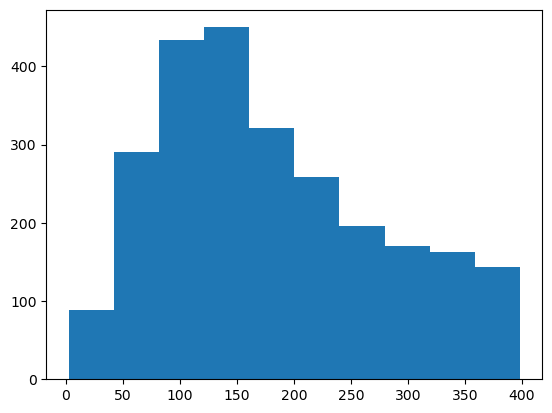

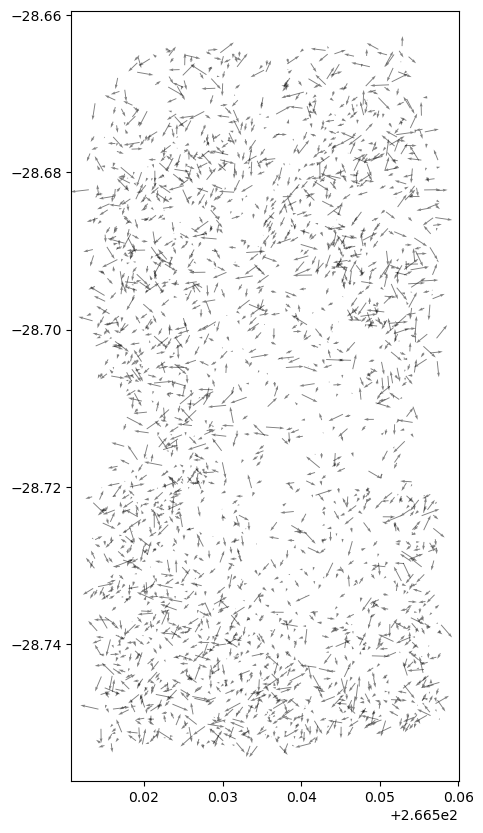

In [51]:
quiver(virac['skycoord'], crd6927, scale=0.0025, max_sep=0.4*u.arcsec)

# compare 2024 = old table to current table

49.1005 marcsec 84.8497 marcsec


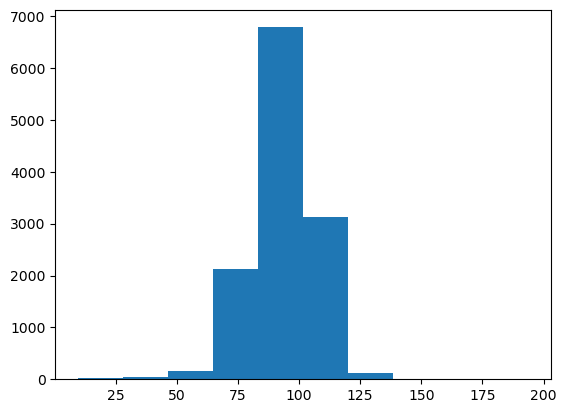

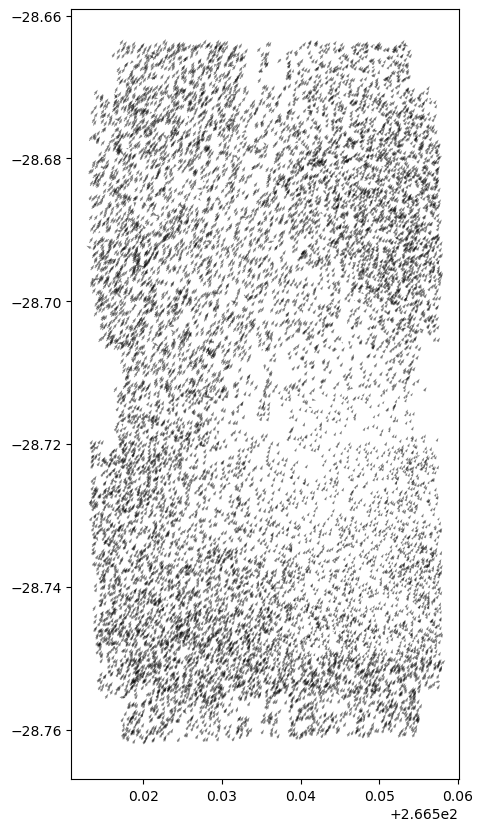

In [52]:
quiver(tb2024['skycoord_ref'], crd, max_sep=0.2*u.arcsec, scale=0.002)

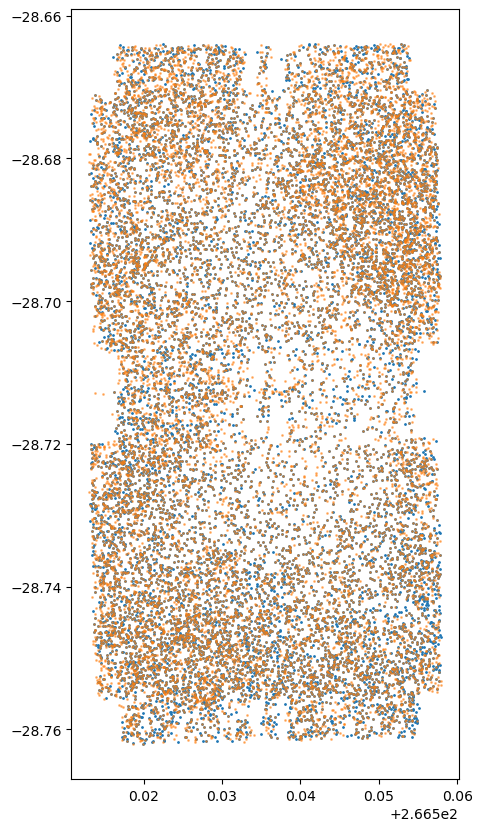

In [53]:
pl.figure(figsize=(5,10));
pl.scatter(tb2024['skycoord_ref'].ra, tb2024['skycoord_ref'].dec, s=1)
pl.scatter(tb[bright]['skycoord_ref'].ra, tb[bright]['skycoord_ref'].dec, s=1, alpha=0.5)

# Special Stars

The above bulk criteria were good, but they left out some good options

266.53035446671424 -28.759076118071988 # super red, yso?
266.51738037065854 -28.70921096494043 # PN
266.5574875383616 -28.729020686218746 # YSO
266.54435668464873 -28.752773212863413 # YSO?
266.53193918693665 -28.755809228333167 # YSO?

In [54]:
basetable.colnames[:35]

['ra',
 'dec',
 'f212n_flux',
 'f212n_flux_err',
 'f212n_qfit',
 'f212n_cfit',
 'f212n_flux_init',
 'f212n_flags',
 'f212n_local_bkg',
 'f212n_group_size',
 'f212n_dra',
 'f212n_ddec',
 'f212n_std_ra',
 'f212n_std_dec',
 'f212n_nmatch',
 'f212n_nmatch_good',
 'f212n_flux_err_prop',
 'f212n_is_saturated',
 'f212n_replaced_saturated',
 'f212n_iter_found',
 'f212n_prominence',
 'f212n_peak_sb',
 'f212n_flux_jy',
 'f212n_eflux_jy',
 'f212n_mag_vega',
 'f212n_emag_vega',
 'f212n_mag_ab',
 'f212n_emag_ab',
 'f212n_ra',
 'f212n_dec',
 'f212n_detected',
 'f115w_flux',
 'f115w_flux_err',
 'f115w_qfit',
 'f115w_cfit']

In [55]:
def missing_or_faint(column, limit=21):
    return column.mask | (column.filled(np.inf) > limit) | np.isnan(column.filled(np.nan))

In [56]:
only405ish_sanity_check =  ((basetable['f410m_emag_vega'] < 0.05) & (basetable['f405n_emag_vega'] < 0.05) &
 (basetable['f212n_mag_vega'].mask) &
 (basetable['f182m_mag_vega'].mask) &
 (basetable['f187n_mag_vega'].mask)
)
only405ish_sanity_check.sum()

np.int64(435)

In [57]:
notbad.sum(), notbad.shape, len(tb)

(np.int64(17379), (684868,), 684868)

1794


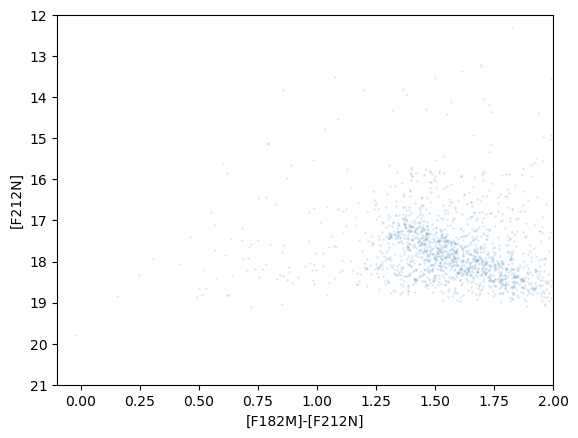

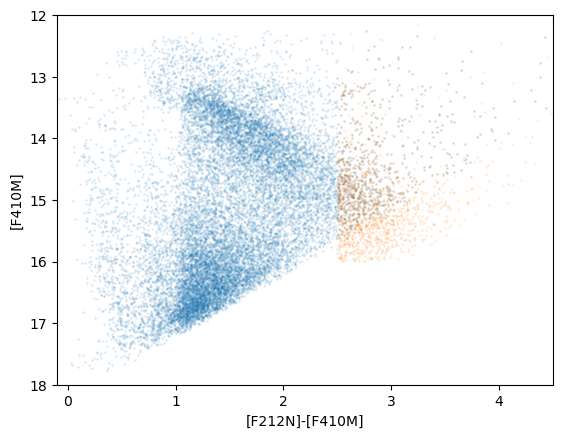

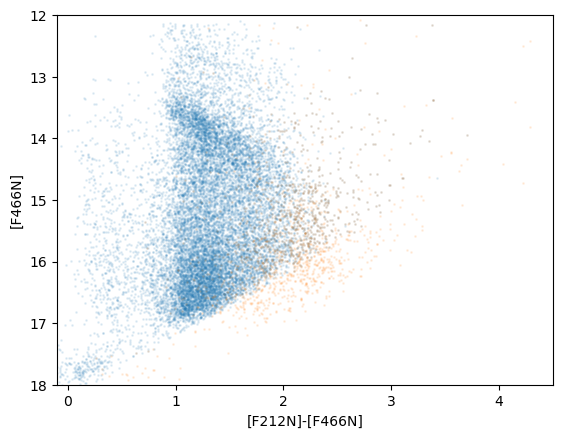

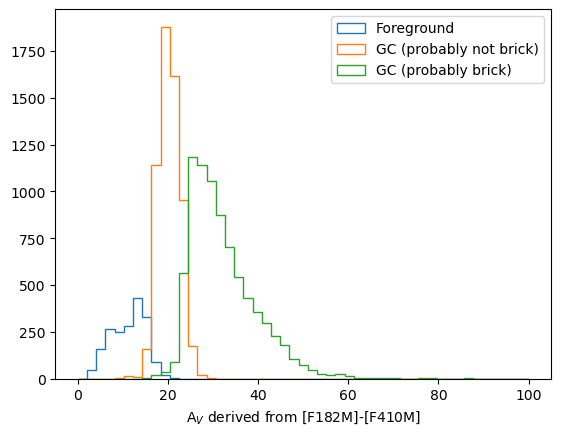

In [58]:
extremely_red = ((basetable['f212n_emag_vega'] < 0.1) &
                 (basetable['f212n_nmatch_good'] > 4) &
                 # 212-410 is red and 410 is bright _or_ 212 is faint and f410 is saturated
                 ((
                     ((basetable['f212n_mag_vega'] - basetable['f410m_mag_vega']) > 2.5) & 
                     (basetable['f410m_mag_vega'] < 16)
                  ) | 
                  ((basetable['f212n_mag_vega'] > 16) & (basetable['f410m_is_saturated']))
                 ) |
                 (basetable['f410m_is_saturated'] & (~basetable['f405n_is_saturated']) & (basetable['f212n_mag_vega'] > 15))
                )

print(extremely_red.sum())
#extremely_red |= only405ish
          

pl.scatter((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega'])[extremely_red], basetable['f212n_mag_vega'][extremely_red], s=1, alpha=0.1)
incl = wholebrickreg.contains(basetable['skycoord_ref'], ww) & extremely_red
#pl.scatter((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega'])[incl], basetable['f212n_mag_vega'][incl], s=1, alpha=0.1)
#pl.scatter((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega'])[bright], basetable['f212n_mag_vega'][bright], s=1, alpha=0.1)
pl.axis([-0.1, 2, 21, 12]);
pl.xlabel("[F182M]-[F212N]")
pl.ylabel("[F212N]");

pl.figure()
pl.scatter((basetable['f212n_mag_vega'] - basetable['f410m_mag_vega'])[notbad], basetable['f410m_mag_vega'][notbad], s=1, alpha=0.1)
pl.scatter((basetable['f212n_mag_vega'] - basetable['f410m_mag_vega'])[extremely_red], basetable['f410m_mag_vega'][extremely_red], s=1, alpha=0.1)
incl = wholebrickreg.contains(basetable['skycoord_ref'], ww) & extremely_red
#pl.scatter((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega'])[incl], basetable['f212n_mag_vega'][incl], s=1, alpha=0.1)
#pl.scatter((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega'])[bright], basetable['f212n_mag_vega'][bright], s=1, alpha=0.1)
pl.axis([-0.1, 4.5, 18, 12]);
pl.xlabel("[F212N]-[F410M]")
pl.ylabel("[F410M]");

pl.figure()
pl.scatter((basetable['f212n_mag_vega'] - basetable['f466n_mag_vega'])[notbad], basetable['f466n_mag_vega'][notbad], s=1, alpha=0.1)
pl.scatter((basetable['f212n_mag_vega'] - basetable['f466n_mag_vega'])[extremely_red], basetable['f466n_mag_vega'][extremely_red], s=1, alpha=0.1)
incl = wholebrickreg.contains(basetable['skycoord_ref'], ww) & extremely_red
#pl.scatter((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega'])[incl], basetable['f212n_mag_vega'][incl], s=1, alpha=0.1)
#pl.scatter((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega'])[bright], basetable['f212n_mag_vega'][bright], s=1, alpha=0.1)
pl.axis([-0.1, 4.5, 18, 12]);
pl.xlabel("[F212N]-[F466N]")
pl.ylabel("[F466N]");

pl.figure()
pl.hist(av182410[bright & ((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega']) < 0.5)], bins=np.linspace(0, 100),
        label='Foreground', histtype='step', density=False);
pl.hist(av182410[bright & ((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega']) < 0.75) & ((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega']) > 0.5)], bins=np.linspace(0, 100),
        label='GC (probably not brick)', histtype='step', density=False);
pl.hist(av182410[bright & ((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega']) > 0.75)], bins=np.linspace(0, 100),
        label='GC (probably brick)', histtype='step', density=False);
pl.legend(loc='best');
pl.xlabel("A$_V$ derived from [F182M]-[F410M]");


1094


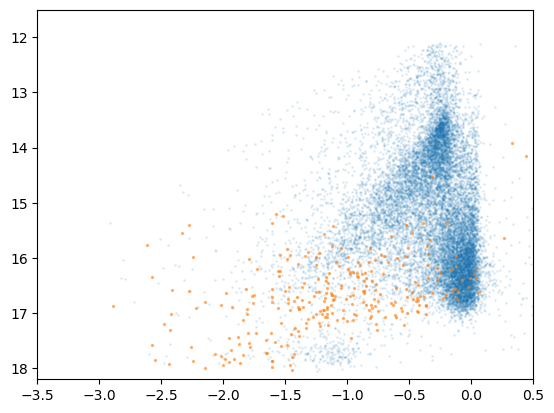

In [59]:
# 405-410 detections, all others nondetected
only405ish = (((basetable['f410m_emag_vega'] < 0.05) &
               (basetable['f405n_emag_vega'] < 0.05) &
               (~basetable['f405n_is_saturated']) &
               (~basetable['f410m_is_saturated']) &
       (missing_or_faint(basetable['f212n_mag_vega'])) &
       (missing_or_faint(basetable['f187n_mag_vega'])) &
       (missing_or_faint(basetable['f182m_mag_vega']))
     ))
print(only405ish.sum())
assert only405ish.sum() > only405ish_sanity_check.sum()
pl.scatter((basetable['f405n_mag_vega'] - basetable['f466n_mag_vega'])[notbad], basetable['f466n_mag_vega'][notbad], s=1, alpha=0.1)
pl.scatter((basetable['f405n_mag_vega'] - basetable['f466n_mag_vega'])[only405ish], basetable['f466n_mag_vega'][only405ish], s=2, alpha=0.5)
pl.xlim(-3.5, 0.5)
pl.ylim(18.2, 11.5);

In [60]:
tb[extremely_red].write('/Users/adam/Dropbox/brick2221/20260714_m7_merged_catalog_NIRSPEC6927_extremered.fits', overwrite=True)
tb[only405ish].write('/Users/adam/Dropbox/brick2221/20260714_m7_merged_catalog_NIRSPEC6927_only405410.fits', overwrite=True)

In [61]:
 # get blue stars in 405-466  = CO, but not require detection at shorter wavelengths
 # exclude 'bright' so that this is a disjoint set

CO_and_not_NIR = ((basetable['f405n_mag_vega'] - basetable['f466n_mag_vega'] < -1) & (basetable['f405n_nmatch_good'] > 4) & (basetable['f466n_nmatch_good'] > 4) & (~bright))
tb[CO_and_not_NIR].write('/Users/adam/Dropbox/brick2221/20260714_m7_merged_catalog_NIRSPEC6927_iced_not_NIR.fits', overwrite=True)

In [62]:
special = SkyCoord([
[266.53035446671424, -28.759076118071988], # super red, yso?
[266.51738037065854, -28.70921096494043 ],# PN
[266.5574875383616 ,-28.729020686218746 ],# YSO
[266.54435668464873, -28.752773212863413], # YSO?
[266.53193918693665, -28.755809228333167] # YSO?
]*u.deg, frame='icrs')
rslt = tb['skycoord_ref'].search_around_sky(special, 0.1*u.arcsec)
assert len(rslt.indices_to_second_set) == len(special)
tb[rslt.indices_to_second_set].write('/Users/adam/Dropbox/brick2221/20260714_m7_merged_catalog_NIRSPEC6927_special.fits', overwrite=True)

In [63]:
special_mask = np.zeros(len(tb), dtype='bool')
special_mask[rslt.indices_to_second_set] = True

In [64]:
tb['selection_criteria'] = '              '
tb['selection_criteria'][bright] = '14<f212<18 & good'
tb['selection_criteria'][special_mask] = 'special / by hand'
tb['selection_criteria'][CO_and_not_NIR] = 'CO not NIR'
tb['selection_criteria'][extremely_red] = 'extremely red'
tb['selection_criteria'][only405ish] = '405/410 w/o NIR'

tb['WEIGHT'][special_mask] = 320
tb['WEIGHT'][only405ish] = 160
tb['WEIGHT'][extremely_red] = 80
tb['WEIGHT'][CO_and_not_NIR] = 80

tb[special_mask | CO_and_not_NIR | extremely_red | only405ish | bright].write('/Users/adam/Dropbox/brick2221/20260714_m7_merged_catalog_NIRSPEC6927_with_extra_categories.fits', overwrite=True)

/var/folders/7f/mm9b53fx2qv6nz9y93yc4l000000gt/T/ipykernel_12485/1295389948.py:2: StringTruncateWarning: truncated right side string(s) longer than 14 character(s) during assignment
  tb['selection_criteria'][bright] = '14<f212<18 & good'
/var/folders/7f/mm9b53fx2qv6nz9y93yc4l000000gt/T/ipykernel_12485/1295389948.py:3: StringTruncateWarning: truncated right side string(s) longer than 14 character(s) during assignment
  tb['selection_criteria'][special_mask] = 'special / by hand'
/var/folders/7f/mm9b53fx2qv6nz9y93yc4l000000gt/T/ipykernel_12485/1295389948.py:6: StringTruncateWarning: truncated right side string(s) longer than 14 character(s) during assignment
  tb['selection_criteria'][only405ish] = '405/410 w/o NIR'


In [65]:
np.unique(tb['WEIGHT'])

0
5
10
20
40
80
160
320


In [66]:
((special_mask | CO_and_not_NIR | extremely_red | only405ish) & (~bright)).sum()

np.int64(1133)

In [71]:
(special_mask | CO_and_not_NIR | extremely_red | only405ish | bright).sum()

np.int64(16033)

## purely for catalog diagnostics

these stars are not weird, they're just luminous; probably most are reddened supergiants.  some could be O-stars, I guess?

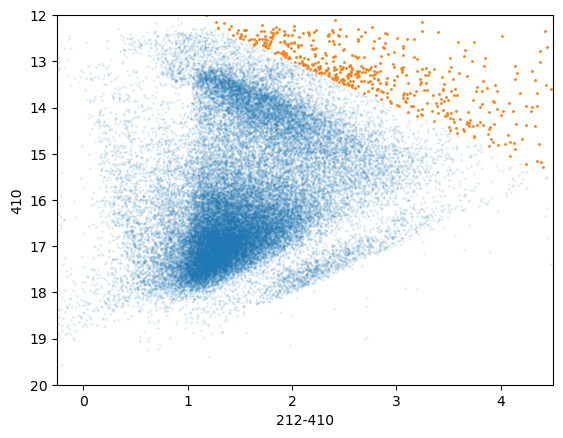

In [67]:
# 1, 12.5
# 4, 15
dx = (4 - 1)
dy = (15 - 12.)
m = dy/dx
b = 12. - m * 1
weird = (tb['f410m_mag_vega'] < (tb['f212n_mag_vega'] - tb['f410m_mag_vega']) * m + b)
weird.sum()
pl.scatter((tb['f212n_mag_vega'] - tb['f410m_mag_vega']), tb['f410m_mag_vega'], s=1, alpha=0.1)
pl.scatter((tb['f212n_mag_vega'] - tb['f410m_mag_vega'])[weird], tb['f410m_mag_vega'][weird], s=1)
pl.ylim(20, 12)
pl.xlim(-0.25, 4.5);
tb[weird].write('/Users/adam/Dropbox/brick2221/20260714_m7_merged_catalog_weirdstars.fits', overwrite=True)
pl.xlabel("212-410")
pl.ylabel('410');